In [101]:
#Importing necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsbombpy import sb
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch
import matplotlib.ticker as ticker
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import warnings
from statsbombpy.api_client import NoAuthWarning
warnings.filterwarnings("ignore", category=NoAuthWarning)

pd.set_option("display.max_columns", None)


#### Data Loading

In [102]:
df_matches = sb.matches(competition_id=11, season_id=27)
df_matches.shape

(380, 22)

In [103]:
df_matches.sample()

,match_id,match_date,kick_off,competition,season,home_team,away_team,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_stage,stadium,referee,home_managers,away_managers,data_version,shot_fidelity_version,xy_fidelity_version
36,3825889,2016-04-16,22:05:00.000,Spain - La Liga,2015/2016,Celta Vigo,Real Betis,1,1,available,unscheduled,2022-03-22T17:30:41.825416,None,33,Regular Season,Abanca-Balaídos,Ricardo De Burgos Bengoetxea,Manuel Eduardo Berizzo,Juan Merino Ruíz,1.1.0,2,2


In [104]:
all_events = []

for match_id in df_matches["match_id"]:
    events = sb.events(match_id=match_id)
    events["match_id"] = match_id
    all_events.append(events)

df_events = pd.concat(all_events, ignore_index=True)
df_events.shape

(1295354, 117)

#### Top 10 Eventos

Das 92 colunas do dataset StatsBomb, 27 representam tipos distintos de ação.  
A celula abaixo mostra a distribuicao de ocorrencias por tipo de evento
em toda a temporada — útil para justificar o foco em passes.

In [105]:
EXCLUIR = [
    'Ball Receipt*',
    'Carry',
    'Half Start',
    'Half End',
    'Starting XI',
    'Substitution',
    'Tactical Shift',
    'Player On',
    'Player Off',
    'Injury Stoppage',
    'Shield',
]

df_tatico = df_events[~df_events['type'].isin(EXCLUIR)]
event_counts = df_tatico['type'].value_counts()
event_counts_pct = (event_counts / event_counts.sum() * 100).round(1)

top10 = event_counts.head(10)
top10_pct = event_counts_pct.head(10)

print(f'Tipos de evento originais:   {df_events["type"].nunique()}')
print(f'Tipos taticos (apos filtro): {df_tatico["type"].nunique()}')
print(f'Top 10 representam {top10_pct.sum():.1f}% dos eventos taticos')
print()
for tipo, pct in top10_pct.items():
    print(f'  {tipo:<25} {pct:>5.1f}%')

Tipos de evento originais:   33
Tipos taticos (apos filtro): 22
Top 10 representam 92.5% dos eventos taticos

  Pass                       53.6%
  Pressure                   16.8%
  Ball Recovery               5.7%
  Duel                        4.6%
  Clearance                   2.4%
  Dribble                     2.1%
  Block                       2.0%
  Interception                1.8%
  Foul Committed              1.8%
  Foul Won                    1.7%


Salvo: ../figures/fig_top10_eventos_pt.png


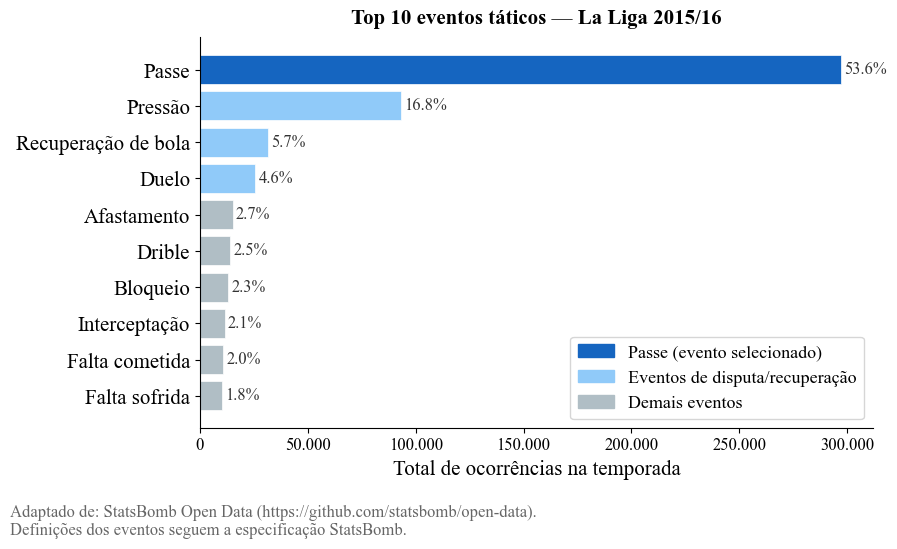

In [107]:
"""
Top 10 eventos táticos — La Liga 2015/16 (rótulos em português)
Valores extraídos da análise exploratória original (01_eda_v1.ipynb).
Adaptado de StatsBomb Open Data.
"""
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Dados (extraídos do notebook EDA) ────────────────────────────────────────
eventos = [
    "Passe",
    "Pressão",
    "Recuperação de bola",
    "Duelo",
    "Afastamento",
    "Drible",
    "Bloqueio",
    "Interceptação",
    "Falta cometida",
    "Falta sofrida",
]

# contagens absolutas (ordem decrescente, do notebook original)
contagens = [297_180, 93_123, 31_637, 25_579, 15_164, 14_112, 13_032, 11_437, 10_891, 10_123]
pcts      = [   53.6,   16.8,    5.7,    4.6,    2.7,    2.5,    2.3,    2.1,    2.0,    1.8]

# ── Cores ─────────────────────────────────────────────────────────────────────
colors = [
    '#1565C0',   # Passe — destaque principal
    '#90CAF9',   # Pressão
    '#90CAF9',   # Recuperação de bola
    '#90CAF9',   # Duelo
    '#B0BEC5',   # demais
    '#B0BEC5',
    '#B0BEC5',
    '#B0BEC5',
    '#B0BEC5',
    '#B0BEC5',
]

# ── Figura ───────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(9, 5))

y = np.arange(len(eventos))
bars = ax.barh(y, contagens, color=colors, edgecolor='white', linewidth=0.5)

# rótulos de percentual à direita de cada barra
for i, (v, pct) in enumerate(zip(contagens, pcts)):
    ax.text(v + 1_500, i, f'{pct:.1f}%', va='center', fontsize=12, color='#333')

ax.set_yticks(y)
ax.set_yticklabels(eventos, fontsize=15)
ax.invert_yaxis()
ax.set_xlabel('Total de ocorrências na temporada', fontsize=15)
ax.set_title('Top 10 eventos táticos — La Liga 2015/16', fontsize=15,
             fontweight='bold', pad=10)
ax.tick_params(axis='x', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'.replace(',', '.')))

# legenda
leg = [
    mpatches.Patch(color='#1565C0', label='Passe (evento selecionado)'),
    mpatches.Patch(color='#90CAF9', label='Eventos de disputa/recuperação'),
    mpatches.Patch(color='#B0BEC5', label='Demais eventos'),
]
ax.legend(handles=leg, fontsize=13, loc='lower right', framealpha=0.8)

# nota de fonte
fig.text(0.01, -0.02,
         'Adaptado de: StatsBomb Open Data (https://github.com/statsbomb/open-data).\n'
         'Definições dos eventos seguem a especificação StatsBomb.',
         fontsize=12, color='#666', va='top')

plt.tight_layout()

out = "../figures/fig_top10_eventos_pt.png"
plt.savefig(out, bbox_inches="tight", dpi=200, facecolor="white")
print(f"Salvo: {out}")
plt.show()

#### Distribuição de Gols  
Análise da distribuição de gols na La Liga 2015/16.

In [108]:
goals = df_events[
    (df_events["type"] == "Shot") &
    (df_events["shot_outcome"] == "Goal")
].copy()

gols_por_partida = (
    goals.groupby("match_id")
         .size()
         .reset_index(name="gols")
)

gols_partidas_com_zero = (
    df_matches[["match_id"]]
    .merge(gols_por_partida, on="match_id", how="left")
    .fillna({"gols": 0})
)

Salvo: ../figures/fig_histograma_gols_por_partida.png


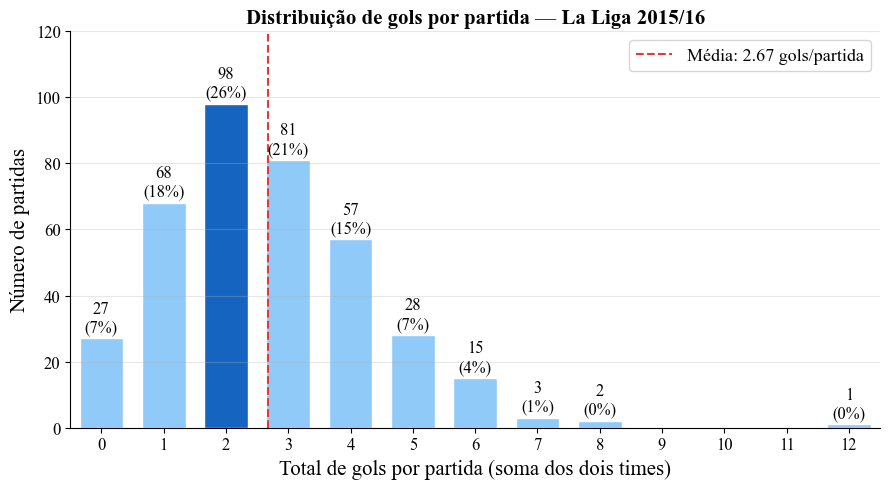

In [109]:
contagem = (
    gols_partidas_com_zero['gols']
        .value_counts()
        .sort_index()
)
max_gols = int(contagem.index.max())
pct = (contagem / contagem.sum() * 100).round(1)

colors = ['#1565C0' if x == contagem.idxmax() else '#90CAF9' for x in contagem.index]

plt.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(contagem.index, contagem.values, color=colors, edgecolor='white', width=0.7)

for x, y, p in zip(contagem.index, contagem.values, pct.values):
    ax.text(x, y + 1.0, f'{y}\n({p:.0f}%)', ha='center', va='bottom', fontsize=12)

ax.set_xlabel('Total de gols por partida (soma dos dois times)', fontsize=15)
ax.set_ylabel('Número de partidas', fontsize=15)
ax.set_title(
    'Distribuição de gols por partida — La Liga 2015/16',
    fontsize=15,
    fontweight='bold'
)
ax.set_ylim(0, 120)
ax.set_xticks(range(0, max_gols + 1))
ax.set_xlim(-0.5, max_gols + 0.5)
ax.tick_params(axis='both', labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

media = gols_partidas_com_zero['gols'].mean()
ax.axvline(media, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'Média: {media:.2f} gols/partida')
ax.legend(fontsize=13)

plt.tight_layout()

out = "../figures/fig_histograma_gols_por_partida.png"
plt.savefig(out, bbox_inches="tight", dpi=200, facecolor="white")
print(f"Salvo: {out}")

plt.show()


In [110]:
# Percentual de gols marcados em casa vs fora
home_gols = df_matches['home_score'].sum()
away_gols = df_matches['away_score'].sum()
total_gols = home_gols + away_gols
print(f'Gols em casa: {home_gols} ({100*home_gols/total_gols:.1f}%)')
print(f'Gols fora:    {away_gols} ({100*away_gols/total_gols:.1f}%)')
print(f'Total:        {total_gols}')
print()

# Percentual de gols open play vs bola parada
BOLA_PARADA = ['Free Kick', 'Penalty', 'Corner']
n_total_gols = len(goals)
n_open_play = len(goals[~goals['shot_type'].isin(BOLA_PARADA)])
n_bola_parada = n_total_gols - n_open_play
print(f'Gols total:       {n_total_gols}')
print(f'Gols open play:   {n_open_play} ({100*n_open_play/n_total_gols:.1f}%)')
print(f'Gols bola parada: {n_bola_parada} ({100*n_bola_parada/n_total_gols:.1f}%)')


Gols em casa: 615 (59.0%)
Gols fora:    428 (41.0%)
Total:        1043

Gols total:       1014
Gols open play:   916 (90.3%)
Gols bola parada: 98 (9.7%)


In [111]:
# Percentual de quantidade de gols por partida
# contagem de partidas por número de gols
dist_gols = (
    gols_partidas_com_zero["gols"]
        .value_counts()
        .sort_index()
)

# percentual
percentual = (dist_gols / dist_gols.sum()) * 100

percentual


gols
0.0      7.105263
1.0     17.894737
2.0     25.789474
3.0     21.315789
4.0     15.000000
5.0      7.368421
6.0      3.947368
7.0      0.789474
8.0      0.526316
12.0     0.263158
Name: count, dtype: float64

In [112]:
# Quantidade de partidas com total zero gol por home time

partidas_zero_zero = (
    gols_partidas_com_zero
        .query("gols == 0")[["match_id"]]
)

zero_zero_home = (
    partidas_zero_zero
        .merge(
            df_matches[["match_id", "home_team"]],
            on="match_id",
            how="left"
        )
)

zero_zero_por_home = (
    zero_zero_home
        .groupby("home_team")["match_id"]
        .count()
        .rename("zero_zero_home")
)

total_home = (
    df_matches
        .groupby("home_team")["match_id"]
        .count()
        .rename("jogos_home")
)

tabela_zero_zero_home = (
    pd.concat([total_home, zero_zero_por_home], axis=1)
      .fillna(0)
)

tabela_zero_zero_home["pct_zero_zero_home"] = (
    tabela_zero_zero_home["zero_zero_home"] /
    tabela_zero_zero_home["jogos_home"] * 100
)

tabela_zero_zero_home = tabela_zero_zero_home.sort_values(
    "pct_zero_zero_home", ascending=False
)

tabela_zero_zero_home


,jogos_home,zero_zero_home,pct_zero_zero_home
home_team,,,
Málaga,19,3.0,15.789474
Las Palmas,19,3.0,15.789474
Real Sociedad,19,2.0,10.526316
Atlético Madrid,19,2.0,10.526316
Athletic Club,19,2.0,10.526316
Celta Vigo,19,2.0,10.526316
Villarreal,19,2.0,10.526316
Espanyol,19,1.0,5.263158
Getafe,19,1.0,5.263158


In [113]:
home = df_matches[["match_id", "home_team"]].rename(columns={"home_team": "team"})
away = df_matches[["match_id", "away_team"]].rename(columns={"away_team": "team"})

todos_times_partidas = pd.concat([home, away], ignore_index=True)

gols_time_partida = (
    goals.groupby(["match_id", "team"])
         .size()
         .reset_index(name="gols")
)

gols_time_partida_com_zero = (
    todos_times_partidas
    .merge(gols_time_partida, on=["match_id", "team"], how="left")
    .fillna({"gols": 0})
)

gols_time_partida_com_zero.head()

,match_id,team,gols
0,3825848,Levante UD,2.0
1,3825895,Las Palmas,2.0
2,3825894,RC Deportivo La Coruña,0.0
3,3825855,Málaga,3.0
4,3825908,Espanyol,4.0


#### Minuto médio do primeiro gol por período

In [114]:
# Minuto médio do primeiro gol por período (1º e 2º tempo)
df_wide = pd.read_parquet('../data/processed/events_wide_minute.parquet')

gols_wide = df_wide[(df_wide['gol_casa'] + df_wide['gol_fora']) > 0].copy()

first_goal = (
    gols_wide
    .sort_values(['match_id', 'period', 'minute_in_period'])
    .groupby(['match_id', 'period'], as_index=False)
    .first()
)

avg = (
    first_goal
    .groupby('period')['minute_in_period']
    .agg(media='mean', mediana='median', desvio='std')
    .round(1)
)
avg.index = avg.index.map({1: '1º Tempo', 2: '2º Tempo'})
avg.index.name = 'Período'
avg

,media,mediana,desvio
Período,,,
1º Tempo,18.2,16.0,12.5
2º Tempo,18.9,16.0,13.7


#### Gols consecutivos com janela sobreposta

Para cada par de gols consecutivos no mesmo período e mesma partida, calcula o intervalo entre eles.
Pares com intervalo inferior a K minutos têm janelas de avaliação sobrepostas,
exigindo dois alarmes distintos para cobrir ambos os eventos.

In [115]:
import pandas as pd

df = pd.read_parquet('../data/processed/events_wide_minute.parquet')

# Linha com gol open play (qualquer lado)
gols = df[
    df['gol_open_play_casa'].fillna(0).astype(bool) |
    df['gol_open_play_fora'].fillna(0).astype(bool)
][['match_id', 'period', 'minute_in_period']].copy()

gols = gols.sort_values(['match_id', 'period', 'minute_in_period']).reset_index(drop=True)

# Intervalo entre gols consecutivos no mesmo período e partida
gols['prev_min'] = gols.groupby(['match_id', 'period'])['minute_in_period'].shift(1)
pairs = gols.dropna(subset=['prev_min']).copy()
pairs['gap'] = pairs['minute_in_period'] - pairs['prev_min']

print(f'Total de pares de gols consecutivos (mesmo período): {len(pairs)}')
print()
for k in [5, 10, 15]:
    n = (pairs['gap'] < k).sum()
    print(f'K={k}: {n}/{len(pairs)} pares com gap < {k} min ({100*n/len(pairs):.1f}%)')


Total de pares de gols consecutivos (mesmo período): 381

K=5: 75/381 pares com gap < 5 min (19.7%)
K=10: 170/381 pares com gap < 10 min (44.6%)
K=15: 241/381 pares com gap < 15 min (63.3%)


#### Gols com janela incompleta (K=10, meia-pirâmide)

Com K=10 e avaliação meia-pirâmide `[t-K, t]`, gols que ocorrem antes do minuto 10 de cada período têm janela de detecção truncada — não há 10 minutos de histórico disponíveis antes do gol.

Total de gols open play: 916
Janela completa   (>= 10 min): 720  (78.6%)
Janela incompleta (<  10 min): 196  (21.4%)

Período 1: 412 gols | janela incompleta: 94 (22.8%)
Período 2: 504 gols | janela incompleta: 102 (20.2%)


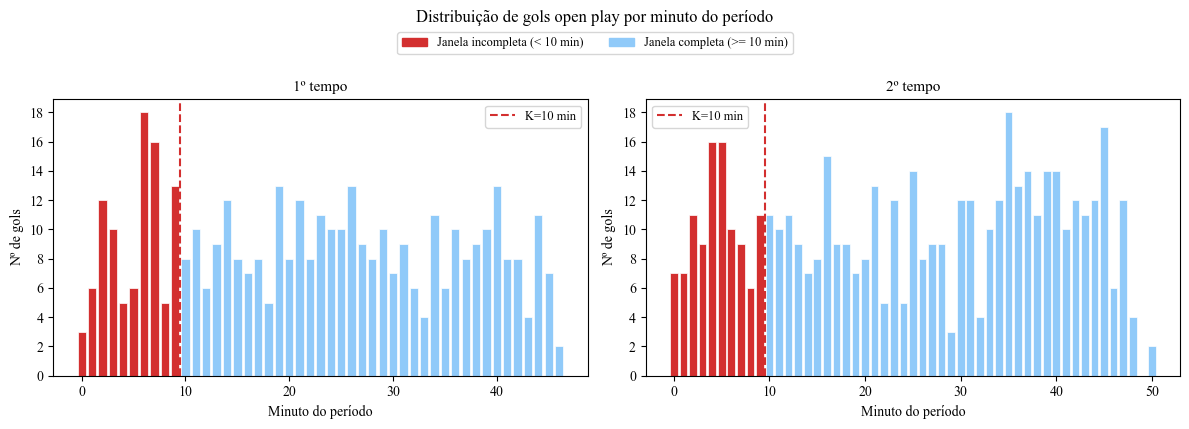

In [116]:
df = pd.read_parquet("../data/processed/events_wide_minute.parquet")

K = 10
df["gol_open_play"] = (
    df["gol_open_play_casa"].fillna(0).astype(bool) |
    df["gol_open_play_fora"].fillna(0).astype(bool)
)

gols = df[df["gol_open_play"]].copy()
total = len(gols)

janela_incompleta = gols["minute_in_period"] < K
n_incompleto = janela_incompleta.sum()
n_completo   = (~janela_incompleta).sum()

print(f"Total de gols open play: {total}")
print(f"Janela completa   (>= {K} min): {n_completo}  ({n_completo/total*100:.1f}%)")
print(f"Janela incompleta (<  {K} min): {n_incompleto}  ({n_incompleto/total*100:.1f}%)")
print()
for p in [1, 2]:
    g = gols[gols["period"] == p]
    inc = (g["minute_in_period"] < K).sum()
    print(f"Período {p}: {len(g)} gols | janela incompleta: {inc} ({inc/len(g)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, period in zip(axes, [1, 2]):
    g = gols[gols["period"] == period]
    counts = g["minute_in_period"].value_counts().sort_index()
    colors = ["#D32F2F" if m < K else "#90CAF9" for m in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(K - 0.5, color="#D32F2F", lw=1.5, ls="--", label=f"K={K} min")
    ax.set_title(f"{period}º tempo", fontsize=11)
    ax.set_xlabel("Minuto do período")
    ax.set_ylabel("Nº de gols")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)

legend_els = [
    Patch(color="#D32F2F", label=f"Janela incompleta (< {K} min)"),
    Patch(color="#90CAF9", label=f"Janela completa (>= {K} min)"),
]
fig.legend(handles=legend_els, loc="upper center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Distribuição de gols open play por minuto do período", fontsize=12, y=1.06)
plt.tight_layout()
plt.savefig("../figures/fig_gols_janela_incompleta_K10.png", bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

Total de gols open play: 916
Janela completa   (>= 5 min): 830  (90.6%)
Janela incompleta (<  5 min): 86  (9.4%)

Período 1: 412 gols | janela incompleta: 36 (8.7%)
Período 2: 504 gols | janela incompleta: 50 (9.9%)


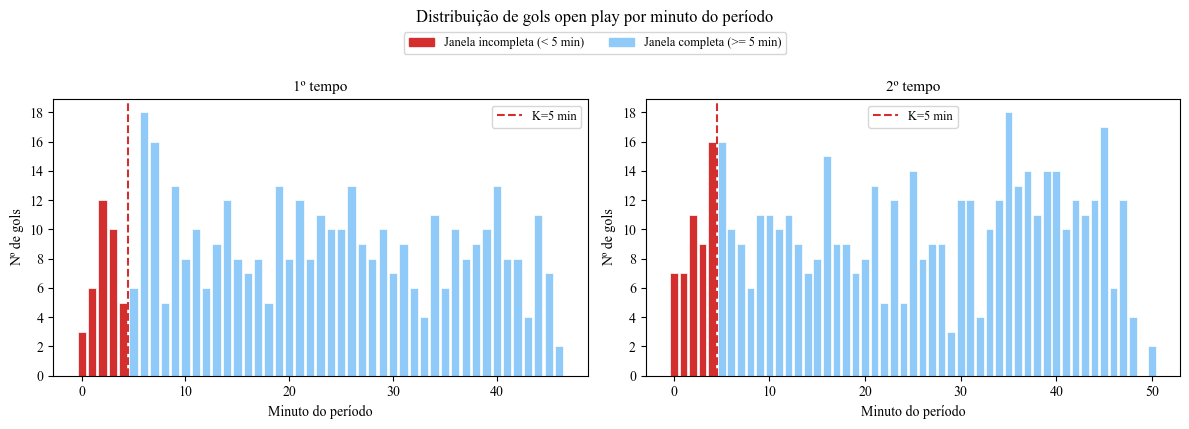

In [117]:
df = pd.read_parquet("../data/processed/events_wide_minute.parquet")

K = 5
df["gol_open_play"] = (
    df["gol_open_play_casa"].fillna(0).astype(bool) |
    df["gol_open_play_fora"].fillna(0).astype(bool)
)

gols = df[df["gol_open_play"]].copy()
total = len(gols)

janela_incompleta = gols["minute_in_period"] < K
n_incompleto = janela_incompleta.sum()
n_completo   = (~janela_incompleta).sum()

print(f"Total de gols open play: {total}")
print(f"Janela completa   (>= {K} min): {n_completo}  ({n_completo/total*100:.1f}%)")
print(f"Janela incompleta (<  {K} min): {n_incompleto}  ({n_incompleto/total*100:.1f}%)")
print()
for p in [1, 2]:
    g = gols[gols["period"] == p]
    inc = (g["minute_in_period"] < K).sum()
    print(f"Período {p}: {len(g)} gols | janela incompleta: {inc} ({inc/len(g)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, period in zip(axes, [1, 2]):
    g = gols[gols["period"] == period]
    counts = g["minute_in_period"].value_counts().sort_index()
    colors = ["#D32F2F" if m < K else "#90CAF9" for m in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(K - 0.5, color="#D32F2F", lw=1.5, ls="--", label=f"K={K} min")
    ax.set_title(f"{period}º tempo", fontsize=11)
    ax.set_xlabel("Minuto do período")
    ax.set_ylabel("Nº de gols")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)

legend_els = [
    Patch(color="#D32F2F", label=f"Janela incompleta (< {K} min)"),
    Patch(color="#90CAF9", label=f"Janela completa (>= {K} min)"),
]
fig.legend(handles=legend_els, loc="upper center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Distribuição de gols open play por minuto do período", fontsize=12, y=1.06)
plt.tight_layout()
plt.savefig("../figures/fig_gols_janela_incompleta_K5.png", bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

#### Gols com janela incompleta (K=15, meia-pirâmide)

Com K=15 e avaliação meia-pirâmide `[t-K, t]`, gols que ocorrem antes do minuto 15 de cada período têm janela de detecção truncada — não há 15 minutos de histórico disponíveis antes do gol.

Total de gols open play: 916
Janela completa   (>= 15 min): 627  (68.4%)
Janela incompleta (<  15 min): 289  (31.6%)

Período 1: 412 gols | janela incompleta: 139 (33.7%)
Período 2: 504 gols | janela incompleta: 150 (29.8%)


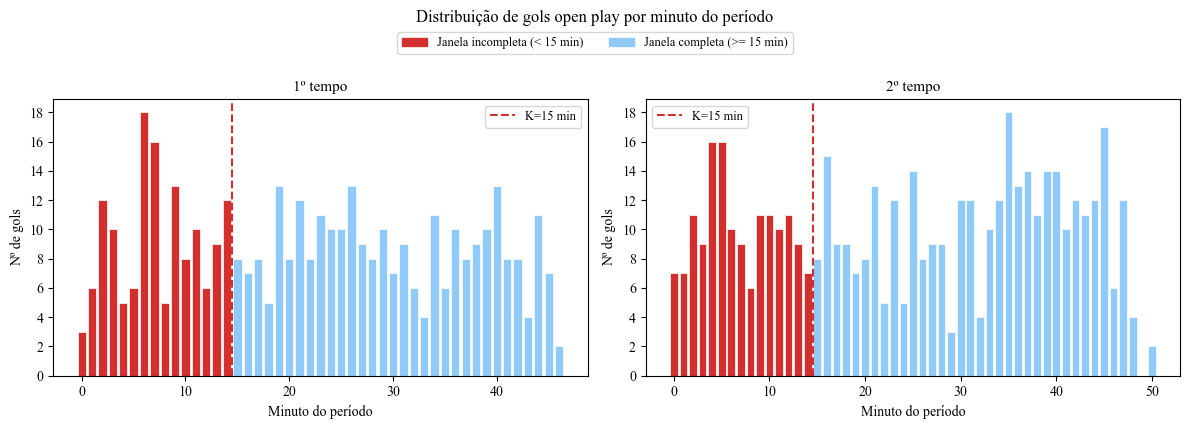

In [118]:
df = pd.read_parquet("../data/processed/events_wide_minute.parquet")

K = 15
df["gol_open_play"] = (
    df["gol_open_play_casa"].fillna(0).astype(bool) |
    df["gol_open_play_fora"].fillna(0).astype(bool)
)

gols = df[df["gol_open_play"]].copy()
total = len(gols)

janela_incompleta = gols["minute_in_period"] < K
n_incompleto = janela_incompleta.sum()
n_completo   = (~janela_incompleta).sum()

print(f"Total de gols open play: {total}")
print(f"Janela completa   (>= {K} min): {n_completo}  ({n_completo/total*100:.1f}%)")
print(f"Janela incompleta (<  {K} min): {n_incompleto}  ({n_incompleto/total*100:.1f}%)")
print()
for p in [1, 2]:
    g = gols[gols["period"] == p]
    inc = (g["minute_in_period"] < K).sum()
    print(f"Período {p}: {len(g)} gols | janela incompleta: {inc} ({inc/len(g)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, period in zip(axes, [1, 2]):
    g = gols[gols["period"] == period]
    counts = g["minute_in_period"].value_counts().sort_index()
    colors = ["#D32F2F" if m < K else "#90CAF9" for m in counts.index]
    ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.5)
    ax.axvline(K - 0.5, color="#D32F2F", lw=1.5, ls="--", label=f"K={K} min")
    ax.set_title(f"{period}º tempo", fontsize=11)
    ax.set_xlabel("Minuto do período")
    ax.set_ylabel("Nº de gols")
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.legend(fontsize=9)

legend_els = [
    Patch(color="#D32F2F", label=f"Janela incompleta (< {K} min)"),
    Patch(color="#90CAF9", label=f"Janela completa (>= {K} min)"),
]
fig.legend(handles=legend_els, loc="upper center", ncol=2, fontsize=9, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Distribuição de gols open play por minuto do período", fontsize=12, y=1.06)
plt.tight_layout()
plt.savefig("../figures/fig_gols_janela_incompleta_K5.png", bbox_inches="tight", dpi=150, facecolor="white")
plt.show()

#### Variação lag10 vs lag10\_antes — versão para dissertação

Mesma análise das células anteriores, mas comparando ataque vs defesa (sem separação 
por mandante/visitante):
- **Top 10 métricas** com labels em inglês (consistente com gráfico de eventos)
- **3 features dos detectores** com labels em português

In [119]:
events = df_events.assign(

    # ==================== ATAQUE ====================
    gol = (
        (df_events["type"] == "Shot") &
        (~df_events['shot_type'].isin(["Free Kick", "Penalty", "Corner"])) &
        (df_events["shot_outcome"] == "Goal")
    ).astype(int),

    chute = (df_events["type"] == "Shot").astype(int),

    chute_bloqueado = (
        (df_events["type"] == "Shot") &
        (df_events["shot_outcome"] == "Blocked")
    ).astype(int),

    drible_certo = (
        (df_events["type"] == "Dribble") &
        (df_events["dribble_outcome"] == "Complete")
    ).astype(int),

    chance = (
    (df_events["type"] == "Shot") &
    (df_events["shot_outcome"].isin(["Saved", "Saved To Post", "Post"]))
    ).astype(int),

    # ==================== PASSES ====================
    passe = (df_events["type"] == "Pass").astype(int),

    passe_certo = (
        (df_events["type"] == "Pass") &
        (df_events["pass_outcome"].isna())
    ).astype(int),

    passe_errado = (
        (df_events["type"] == "Pass") &
        (df_events["pass_outcome"].notna())
    ).astype(int),

    escanteio = (
        (df_events["type"] == "Pass") &
        (df_events["pass_type"] == "Corner")
    ).astype(int),

    cruzamento = (
        (df_events["type"] == "Pass") &
        (df_events["pass_cross"] == True)
    ).astype(int),

    bola_profundidade = (
        (df_events["type"] == "Pass") &
        (df_events["pass_through_ball"] == True)
    ).astype(int),

    # ==================== DEFESA ====================
    falta = (df_events["type"] == "Foul Committed").astype(int),

    duelo_ganho = (
        (df_events["type"] == "Duel") &
        (df_events["duel_outcome"] == "Won")
    ).astype(int),

    interceptacao = (df_events["type"] == "Interception").astype(int),

    recuperacao = (df_events["type"] == "Ball Recovery").astype(int),

    corte = (df_events["type"] == "Clearance").astype(int),

    pressao = (df_events["counterpress"] == True).astype(int),

    cartao = (
        df_events["foul_committed_card"].notna() |
        df_events["bad_behaviour_card"].notna()
    ).astype(int),
)

In [120]:
events["minute_in_period"] = events["minute"]

events.loc[events["period"] == 2, "minute_in_period"] -= 45

In [121]:
events_minuto = (
    events
        .groupby(
            ["match_id", "team", "period", "minute_in_period"],
            as_index=False
        )
        .sum(numeric_only=True)
)

In [122]:
gols = (
    events_minuto
        .query("gol > 0")
        [["match_id", "team", "period", "minute_in_period"]]
        .rename(columns={"minute_in_period": "t"})
)

gols = gols.query("t >= 20")

In [123]:
times_partida = (
    events_minuto[["match_id", "team"]]
        .drop_duplicates()
        .groupby("match_id")["team"]
        .apply(list)
)

In [124]:
metricas_lag = [
    "chute", "chute_bloqueado", "drible_certo", "chance",
    "passe", "passe_certo", "passe_errado",
    "escanteio", "cruzamento", "bola_profundidade",
    "falta", "duelo_ganho", "interceptacao",
    "recuperacao", "corte", "pressao", "cartao",
]


In [125]:
# Gols marcados: cada linha = um gol; team = time que marcou; local = casa/fora DESSE time.
# Casa = marcou jogando em casa; Fora = marcou jogando fora.
# Garantir coluna local (casa/fora) em gols
if "local" not in gols.columns:
    gols = gols.merge(
        df_matches[["match_id", "home_team", "away_team"]], on="match_id", how="left"
    )
    gols["local"] = gols.apply(
        lambda r: "casa" if r["team"] == r["home_team"] else "fora", axis=1
    )

registros = []

for _, g in gols.iterrows():
    match = g["match_id"]
    team = g["team"]
    period = g["period"]
    t = g["t"]
    contexto = g["local"]

    lag10_ini = t - 10
    lag10_fim = t - 1
    lag20_ini = t - 20
    lag20_fim = t - 11

    lag_10 = events_minuto[
        (events_minuto["match_id"] == match) &
        (events_minuto["team"] == team) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag10_ini) &
        (events_minuto["minute_in_period"] <= lag10_fim)
    ]
    lag_20 = events_minuto[
        (events_minuto["match_id"] == match) &
        (events_minuto["team"] == team) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag20_ini) &
        (events_minuto["minute_in_period"] <= lag20_fim)
    ]

    row = {
        "match_id": match,
        "team": team,
        "period": period,
        "minute_goal": t,
        "contexto": contexto,
    }
    for m in metricas_lag:
        row[f"{m}_lag10"] = lag_10[m].sum()
        row[f"{m}_lag20"] = lag_20[m].sum()
    registros.append(row)

lags_ataque_defesa = pd.DataFrame(registros)




In [126]:
for m in metricas_lag:
    lags_ataque_defesa[f"{m}_lag10_pm"] = lags_ataque_defesa[f"{m}_lag10"] / 10
    lags_ataque_defesa[f"{m}_lag20_pm"] = lags_ataque_defesa[f"{m}_lag20"] / 10

In [127]:
for m in metricas_lag:
    lags_ataque_defesa[f"{m}_diff_pm"] = (
        lags_ataque_defesa[f"{m}_lag10_pm"]
        - lags_ataque_defesa[f"{m}_lag20_pm"]
    )

In [128]:
lags_casa = lags_ataque_defesa.query("contexto == 'casa'")
lags_fora = lags_ataque_defesa.query("contexto == 'fora'")

In [129]:
# Time que sofreu = o outro time da partida; contexto = casa/fora do time que sofreu
if "home_team" not in gols.columns:
    gols = gols.merge(
        df_matches[["match_id", "home_team", "away_team"]], on="match_id", how="left"
    )

registros_sofrer = []
for _, g in gols.iterrows():
    match = g["match_id"]
    team_sofreu = [x for x in times_partida.loc[match] if x != g["team"]][0]
    period = g["period"]
    t = g["t"]
    local_sofreu = "casa" if team_sofreu == g["home_team"] else "fora"

    lag10_ini, lag10_fim = t - 10, t - 1
    lag20_ini, lag20_fim = t - 20, t - 11

    lag_10 = events_minuto[
        (events_minuto["match_id"] == match) &
        (events_minuto["team"] == team_sofreu) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag10_ini) &
        (events_minuto["minute_in_period"] <= lag10_fim)
    ]
    lag_20 = events_minuto[
        (events_minuto["match_id"] == match) &
        (events_minuto["team"] == team_sofreu) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag20_ini) &
        (events_minuto["minute_in_period"] <= lag20_fim)
    ]

    row = {"match_id": match, "team": team_sofreu, "period": period, "minute_goal": t, "contexto": local_sofreu}
    for m in metricas_lag:
        row[f"{m}_lag10"] = lag_10[m].sum()
        row[f"{m}_lag20"] = lag_20[m].sum()
    registros_sofrer.append(row)

lags_sofrer = pd.DataFrame(registros_sofrer)
for m in metricas_lag:
    lags_sofrer[f"{m}_lag10_pm"] = lags_sofrer[f"{m}_lag10"] / 10
    lags_sofrer[f"{m}_lag20_pm"] = lags_sofrer[f"{m}_lag20"] / 10
for m in metricas_lag:
    lags_sofrer[f"{m}_diff_pm"] = lags_sofrer[f"{m}_lag10_pm"] - lags_sofrer[f"{m}_lag20_pm"]


=== Top 10 métricas (janela 10 min) ===


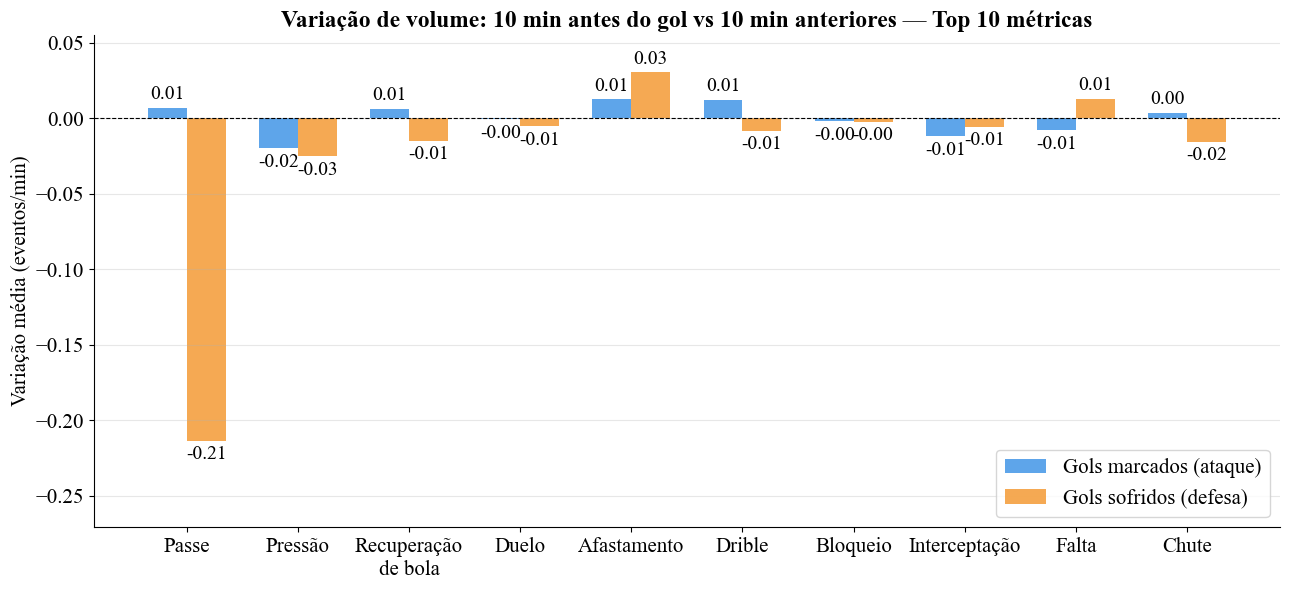

In [130]:
LABELS_EN_10 = {
    'passe': 'Pass', 'pressao': 'Pressure', 'recuperacao': 'Ball Recovery',
    'duelo_ganho': 'Duel', 'corte': 'Clearance', 'drible_certo': 'Dribble',
    'chute_bloqueado': 'Block', 'interceptacao': 'Interception',
    'falta': 'Foul', 'chute': 'Shot',
}
LABELS_PT_10 = {
    'passe': 'Passe', 'passe_certo': 'Passe certo', 'passe_errado': 'Passe errado',
    'pressao': 'Pressão', 'recuperacao': 'Recuperação\nde bola',
    'duelo_ganho': 'Duelo', 'corte': 'Afastamento', 'drible_certo': 'Drible',
    'chute_bloqueado': 'Bloqueio', 'interceptacao': 'Interceptação',
    'falta': 'Falta', 'chute': 'Chute',
}
TOP10 = ['passe', 'pressao', 'recuperacao', 'duelo_ganho',
         'corte', 'drible_certo', 'chute_bloqueado', 'interceptacao', 'falta', 'chute']
TOP10 = [m for m in TOP10 if f'{m}_lag10_pm' in lags_ataque_defesa.columns]

def plot_lag10_comparacao(lags_marcados, lags_sofridos, metricas, labels, titulo_sufixo='', savepath=None):
    # calcula diff_pm = lag10 - lag20 (ritmo antes do gol vs ritmo anterior)
    ataque_vals = {m: lags_marcados[f'{m}_lag10_pm'].mean() - lags_marcados[f'{m}_lag20_pm'].mean()
                   for m in metricas}
    defesa_vals = {m: lags_sofridos[f'{m}_lag10_pm'].mean() - lags_sofridos[f'{m}_lag20_pm'].mean()
                   for m in metricas}
    x = np.arange(len(metricas))
    width = 0.35
    plt.rcParams['font.family'] = 'Times New Roman'
    fig, ax = plt.subplots(figsize=(13 if len(metricas) > 4 else 9, 6))
    bars1 = ax.bar(x - width/2, [ataque_vals[m] for m in metricas],
                   width, label='Gols marcados (ataque)', color='#4C9BE8', alpha=0.9)
    bars2 = ax.bar(x + width/2, [defesa_vals[m] for m in metricas],
                   width, label='Gols sofridos (defesa)', color='#F4A040', alpha=0.9)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([labels.get(m, m) for m in metricas], rotation=0, ha='center', fontsize=12)
    ax.set_ylabel('Variação média (eventos/min)', fontsize=15)
    ax.set_title(
        f'Variação de volume: 10 min antes do gol vs 10 min anteriores{titulo_sufixo}',
        fontsize=17, fontweight='bold'
    )
    ax.legend(fontsize=15, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    offset = 0.003
    for bar in list(bars1) + list(bars2):
        v = bar.get_height()
        if v >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + offset,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=14)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, v - offset,
                    f'{v:.2f}', ha='center', va='top', fontsize=14)
    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin * 1.2, ymax * 1.3)
    ax.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=200, facecolor='white')
    plt.show()

print('=== Top 10 métricas (janela 10 min) ===')
plot_lag10_comparacao(lags_ataque_defesa, lags_sofrer, TOP10, LABELS_PT_10, ' — Top 10 métricas', savepath='../figures/fig_lag10_comparacao_top10.png')


=== 3 features dos detectores (janela 10 min) ===


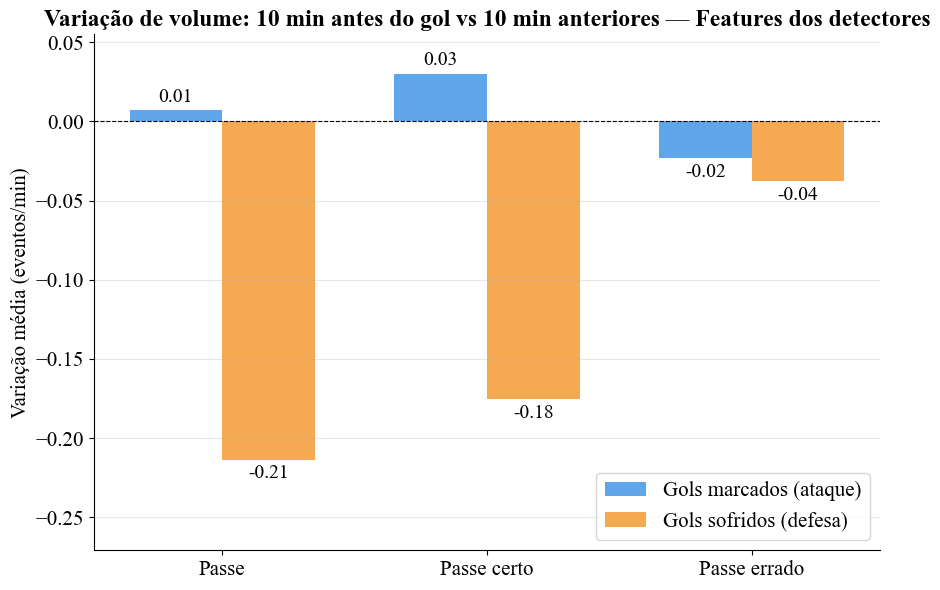

In [131]:
print('=== 3 features dos detectores (janela 10 min) ===')
plot_lag10_comparacao(lags_ataque_defesa, lags_sofrer,
                      ['passe', 'passe_certo', 'passe_errado'],
                      LABELS_PT_10,
                      ' — Features dos detectores')


=== Top 10 métricas — geral (10 min) ===


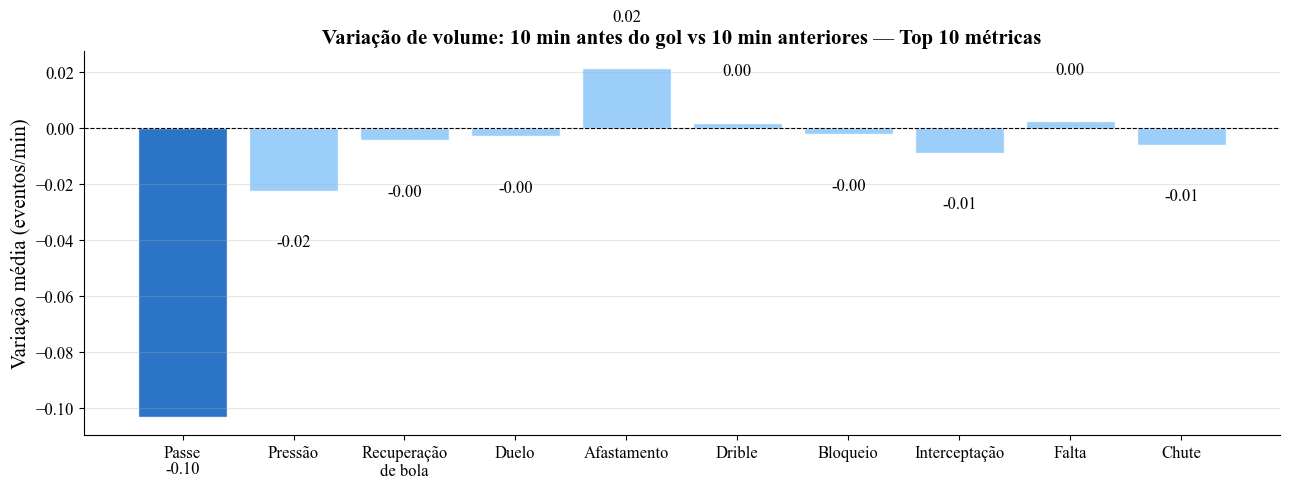

=== Features dos detectores — geral (10 min) ===


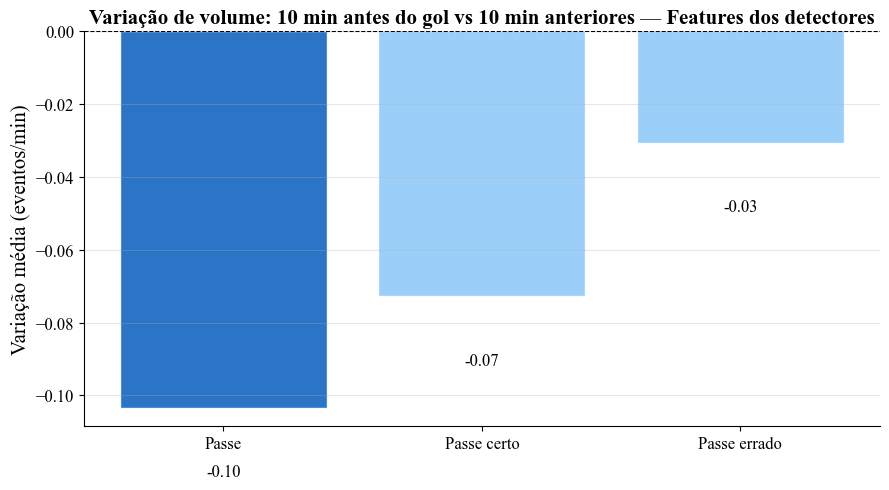

In [132]:
def plot_lag10_geral(lags_marcados, lags_sofridos, metricas, labels, titulo_sufixo='', savepath=None):
    """Variação média geral (10 min) — sem separar gol marcado / sofrido."""
    import numpy as np

    ataque_vals = {m: lags_marcados[f'{m}_lag10_pm'].mean() - lags_marcados[f'{m}_lag20_pm'].mean()
                   for m in metricas}
    defesa_vals = {m: lags_sofridos[f'{m}_lag10_pm'].mean() - lags_sofridos[f'{m}_lag20_pm'].mean()
                   for m in metricas}
    media_vals  = {m: (ataque_vals[m] + defesa_vals[m]) / 2 for m in metricas}

    plt.rcParams['font.family'] = 'Times New Roman'
    fig, ax = plt.subplots(figsize=(13 if len(metricas) > 4 else 9, 5))

    colors = ['#1565C0' if m == 'passe' else '#90CAF9' for m in metricas]
    bars = ax.bar(
        range(len(metricas)),
        [media_vals[m] for m in metricas],
        color=colors, edgecolor='white', alpha=0.9
    )

    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(range(len(metricas)))
    ax.set_xticklabels([labels.get(m, m) for m in metricas], rotation=0, ha='center', fontsize=12)
    ax.set_ylabel('Variação média (eventos/min)', fontsize=15)
    ax.set_title(
        f'Variação de volume: 10 min antes do gol vs 10 min anteriores{titulo_sufixo}',
        fontsize=15, fontweight='bold'
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

    span = max(abs(v) for v in media_vals.values()) * 0.15 or 0.01
    for i, bar in enumerate(bars):
        v = bar.get_height()
        ypos = v + span if v >= 0 else v - span
        va = 'bottom' if v >= 0 else 'top'
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f'{v:.2f}', ha='center', va=va, fontsize=12)

    ax.tick_params(axis='both', labelsize=12)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=200, facecolor='white')
    plt.show()


print('=== Top 10 métricas — geral (10 min) ===')
plot_lag10_geral(lags_ataque_defesa, lags_sofrer, TOP10, LABELS_PT_10, ' — Top 10 métricas', savepath='../figures/fig_lag10_geral_top10.png')

print('=== Features dos detectores — geral (10 min) ===')
plot_lag10_geral(lags_ataque_defesa, lags_sofrer,
                 ['passe', 'passe_certo', 'passe_errado'],
                 LABELS_PT_10, ' — Features dos detectores', savepath='../figures/fig_lag10_geral_features.png')


#### Variação lag5 vs lag5\_antes — versão para dissertação

Mesma análise da janela de 10 min, mas com janela de 5 min: compara os 5 min imediatamente antes do gol com os 5 min anteriores a esses.

In [133]:
# Gols marcados - janela 5 min
gols_5 = gols.query("t >= 11").copy()
if "local" not in gols_5.columns:
    gols_5 = gols_5.merge(df_matches[["match_id", "home_team", "away_team"]], on="match_id", how="left")
    gols_5["local"] = gols_5.apply(lambda r: "casa" if r["team"] == r["home_team"] else "fora", axis=1)

registros_5 = []
for _, g in gols_5.iterrows():
    match, team, period, t = g["match_id"], g["team"], g["period"], g["t"]
    contexto = g["local"]
    lag5_ini, lag5_fim = t - 5, t - 1
    lag5_antes_ini, lag5_antes_fim = t - 10, t - 6

    lag_5 = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag5_ini) & (events_minuto["minute_in_period"] <= lag5_fim)
    ]
    lag_5_antes = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag5_antes_ini) & (events_minuto["minute_in_period"] <= lag5_antes_fim)
    ]
    row = {"match_id": match, "team": team, "period": period, "minute_goal": t, "contexto": contexto}
    for m in metricas_lag:
        row[f"{m}_lag5"] = lag_5[m].sum()
        row[f"{m}_lag5_antes"] = lag_5_antes[m].sum()
    registros_5.append(row)

lags_5min = pd.DataFrame(registros_5)
for m in metricas_lag:
    lags_5min[f"{m}_lag5_pm"]       = lags_5min[f"{m}_lag5"] / 5
    lags_5min[f"{m}_lag5_antes_pm"] = lags_5min[f"{m}_lag5_antes"] / 5
    lags_5min[f"{m}_diff_pm"]       = lags_5min[f"{m}_lag5_pm"] - lags_5min[f"{m}_lag5_antes_pm"]

In [134]:
# Gols sofridos - janela 5 min
if "home_team" not in gols_5.columns:
    gols_5 = gols_5.merge(df_matches[["match_id", "home_team", "away_team"]], on="match_id", how="left")

registros_sofrer_5 = []
for _, g in gols_5.iterrows():
    match = g["match_id"]
    team_sofreu = [x for x in times_partida.loc[match] if x != g["team"]][0]
    period, t = g["period"], g["t"]
    local_sofreu = "casa" if team_sofreu == g["home_team"] else "fora"
    lag5_ini, lag5_fim = t - 5, t - 1
    lag5_antes_ini, lag5_antes_fim = t - 10, t - 6

    lag_5 = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team_sofreu) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag5_ini) & (events_minuto["minute_in_period"] <= lag5_fim)
    ]
    lag_5_antes = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team_sofreu) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag5_antes_ini) & (events_minuto["minute_in_period"] <= lag5_antes_fim)
    ]
    row = {"match_id": match, "team": team_sofreu, "period": period, "minute_goal": t, "contexto": local_sofreu}
    for m in metricas_lag:
        row[f"{m}_lag5"] = lag_5[m].sum()
        row[f"{m}_lag5_antes"] = lag_5_antes[m].sum()
    registros_sofrer_5.append(row)

lags_sofrer_5min = pd.DataFrame(registros_sofrer_5)
for m in metricas_lag:
    lags_sofrer_5min[f"{m}_lag5_pm"]       = lags_sofrer_5min[f"{m}_lag5"] / 5
    lags_sofrer_5min[f"{m}_lag5_antes_pm"] = lags_sofrer_5min[f"{m}_lag5_antes"] / 5
    lags_sofrer_5min[f"{m}_diff_pm"]       = lags_sofrer_5min[f"{m}_lag5_pm"] - lags_sofrer_5min[f"{m}_lag5_antes_pm"]

=== Top 10 métricas (janela 5 min) ===


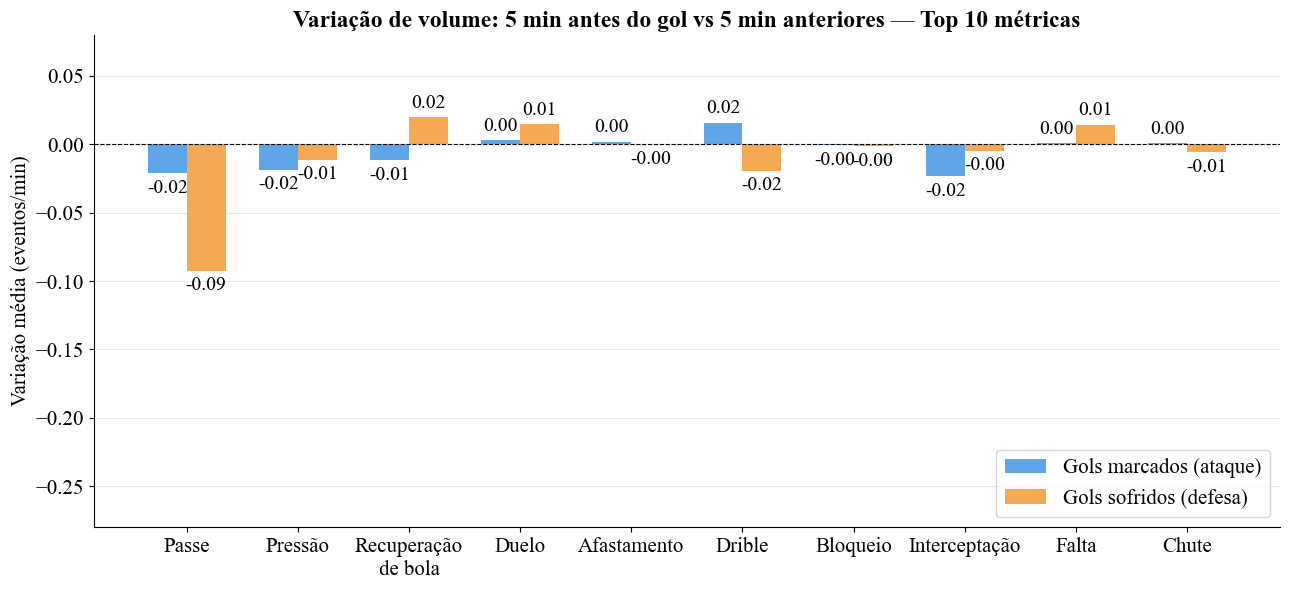

In [135]:
TOP10_METRICAS = [
    'passe', 'pressao', 'recuperacao', 'duelo_ganho',
    'corte', 'drible_certo', 'chute_bloqueado', 'interceptacao', 'falta', 'chute',
]
TOP10_METRICAS = [m for m in TOP10_METRICAS if f'{m}_diff_pm' in lags_5min.columns]

LABELS_PT_5 = {
    'passe': 'Passe', 'passe_certo': 'Passe certo', 'passe_errado': 'Passe errado',
    'pressao': 'Pressão', 'recuperacao': 'Recuperação\nde bola',
    'duelo_ganho': 'Duelo', 'corte': 'Afastamento', 'drible_certo': 'Drible',
    'chute_bloqueado': 'Bloqueio', 'interceptacao': 'Interceptação',
    'falta': 'Falta', 'chute': 'Chute',
}

def plot_lag5_comparacao(lags_marcados, lags_sofridos, metricas, labels, titulo_sufixo='', savepath=None):
    ataque_vals = lags_marcados[[f'{m}_diff_pm' for m in metricas]].mean()
    defesa_vals = lags_sofridos[[f'{m}_diff_pm' for m in metricas]].mean()
    x = np.arange(len(metricas))
    width = 0.35
    plt.rcParams['font.family'] = 'Times New Roman'
    fig, ax = plt.subplots(figsize=(13, 6))
    bars1 = ax.bar(x - width/2, [ataque_vals[f'{m}_diff_pm'] for m in metricas],
                   width, label='Gols marcados (ataque)', color='#4C9BE8', alpha=0.9)
    bars2 = ax.bar(x + width/2, [defesa_vals[f'{m}_diff_pm'] for m in metricas],
                   width, label='Gols sofridos (defesa)', color='#F4A040', alpha=0.9)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([labels.get(m, m) for m in metricas], rotation=0, ha='center', fontsize=12)
    ax.set_ylabel('Variação média (eventos/min)', fontsize=15)
    ax.set_title(
        f'Variação de volume: 5 min antes do gol vs 5 min anteriores{titulo_sufixo}',
        fontsize=17, fontweight='bold'
    )
    ax.legend(fontsize=15, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    offset = 0.004
    for bar in list(bars1) + list(bars2):
        v = bar.get_height()
        if v >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + offset,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=14)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, v - offset,
                    f'{v:.2f}', ha='center', va='top', fontsize=14)
    ax.set_ylim(-0.28, 0.08)
    ax.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=200, facecolor='white')
    plt.show()

print('=== Top 10 métricas (janela 5 min) ===')
plot_lag5_comparacao(lags_5min, lags_sofrer_5min, TOP10_METRICAS, LABELS_PT_5, ' — Top 10 métricas', savepath='../figures/fig_lag5_comparacao_top10.png')

=== 3 features dos detectores (janela 5 min) ===


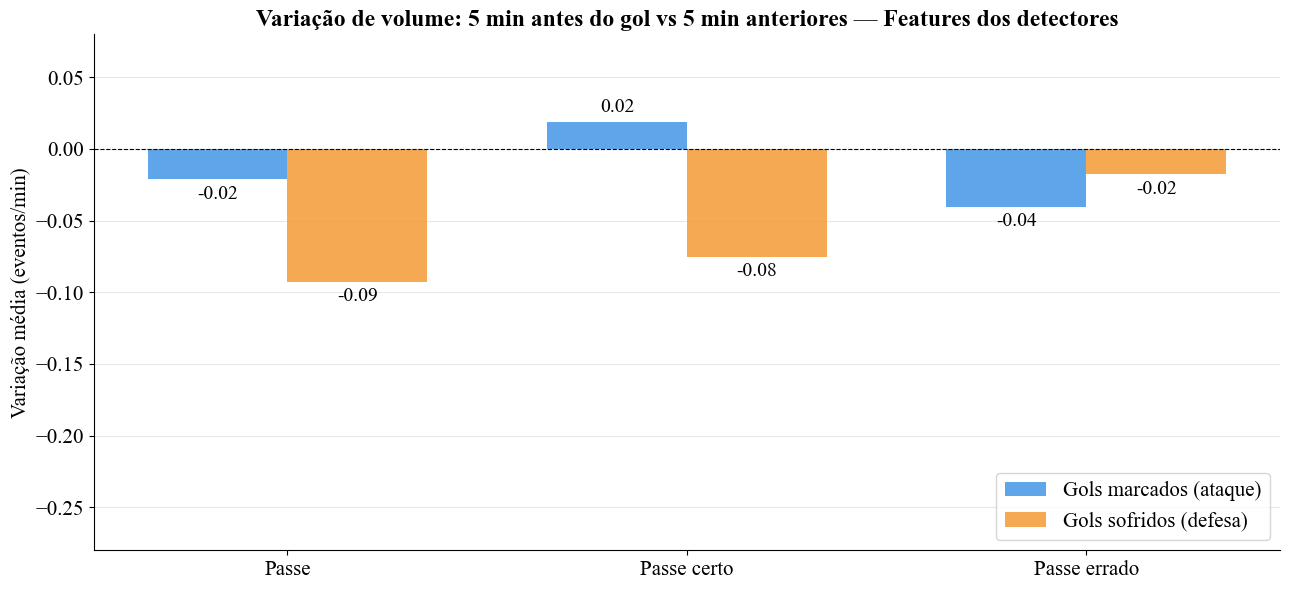

In [136]:
print('=== 3 features dos detectores (janela 5 min) ===')
plot_lag5_comparacao(lags_5min, lags_sofrer_5min,
                     ['passe', 'passe_certo', 'passe_errado'],
                     LABELS_PT_5,
                     ' — Features dos detectores')

#### Variação lag15 vs lag15\_antes — versão para dissertação

Mesma análise da janela de 10 min, mas com janela de 15 min: compara os 15 min imediatamente antes do gol com os 15 min anteriores a esses.

In [137]:
# Gols marcados - janela 15 min
gols_15 = gols.query("t >= 31").copy()
if "local" not in gols_15.columns:
    gols_15 = gols_15.merge(df_matches[["match_id", "home_team", "away_team"]], on="match_id", how="left")
    gols_15["local"] = gols_15.apply(lambda r: "casa" if r["team"] == r["home_team"] else "fora", axis=1)

registros_15 = []
for _, g in gols_15.iterrows():
    match, team, period, t = g["match_id"], g["team"], g["period"], g["t"]
    contexto = g["local"]
    lag15_ini, lag15_fim = t - 15, t - 1
    lag15_antes_ini, lag15_antes_fim = t - 30, t - 16

    lag_15 = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag15_ini) & (events_minuto["minute_in_period"] <= lag15_fim)
    ]
    lag_15_antes = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag15_antes_ini) & (events_minuto["minute_in_period"] <= lag15_antes_fim)
    ]
    row = {"match_id": match, "team": team, "period": period, "minute_goal": t, "contexto": contexto}
    for m in metricas_lag:
        row[f"{m}_lag15"] = lag_15[m].sum()
        row[f"{m}_lag15_antes"] = lag_15_antes[m].sum()
    registros_15.append(row)

lags_15min = pd.DataFrame(registros_15)
for m in metricas_lag:
    lags_15min[f"{m}_lag15_pm"]       = lags_15min[f"{m}_lag15"] / 15
    lags_15min[f"{m}_lag15_antes_pm"] = lags_15min[f"{m}_lag15_antes"] / 15
    lags_15min[f"{m}_diff_pm"]       = lags_15min[f"{m}_lag15_pm"] - lags_15min[f"{m}_lag15_antes_pm"]

In [138]:
# Gols sofridos - janela 15 min
if "home_team" not in gols_15.columns:
    gols_15 = gols_15.merge(df_matches[["match_id", "home_team", "away_team"]], on="match_id", how="left")

registros_sofrer_15 = []
for _, g in gols_15.iterrows():
    match = g["match_id"]
    team_sofreu = [x for x in times_partida.loc[match] if x != g["team"]][0]
    period, t = g["period"], g["t"]
    local_sofreu = "casa" if team_sofreu == g["home_team"] else "fora"
    lag15_ini, lag15_fim = t - 15, t - 1
    lag15_antes_ini, lag15_antes_fim = t - 30, t - 16

    lag_15 = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team_sofreu) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag15_ini) & (events_minuto["minute_in_period"] <= lag15_fim)
    ]
    lag_15_antes = events_minuto[
        (events_minuto["match_id"] == match) & (events_minuto["team"] == team_sofreu) &
        (events_minuto["period"] == period) &
        (events_minuto["minute_in_period"] >= lag15_antes_ini) & (events_minuto["minute_in_period"] <= lag15_antes_fim)
    ]
    row = {"match_id": match, "team": team_sofreu, "period": period, "minute_goal": t, "contexto": local_sofreu}
    for m in metricas_lag:
        row[f"{m}_lag15"] = lag_15[m].sum()
        row[f"{m}_lag15_antes"] = lag_15_antes[m].sum()
    registros_sofrer_15.append(row)

lags_sofrer_15min = pd.DataFrame(registros_sofrer_15)
for m in metricas_lag:
    lags_sofrer_15min[f"{m}_lag15_pm"]       = lags_sofrer_15min[f"{m}_lag15"] / 15
    lags_sofrer_15min[f"{m}_lag15_antes_pm"] = lags_sofrer_15min[f"{m}_lag15_antes"] / 15
    lags_sofrer_15min[f"{m}_diff_pm"]       = lags_sofrer_15min[f"{m}_lag15_pm"] - lags_sofrer_15min[f"{m}_lag15_antes_pm"]

=== Top 10 métricas (janela 15 min) ===


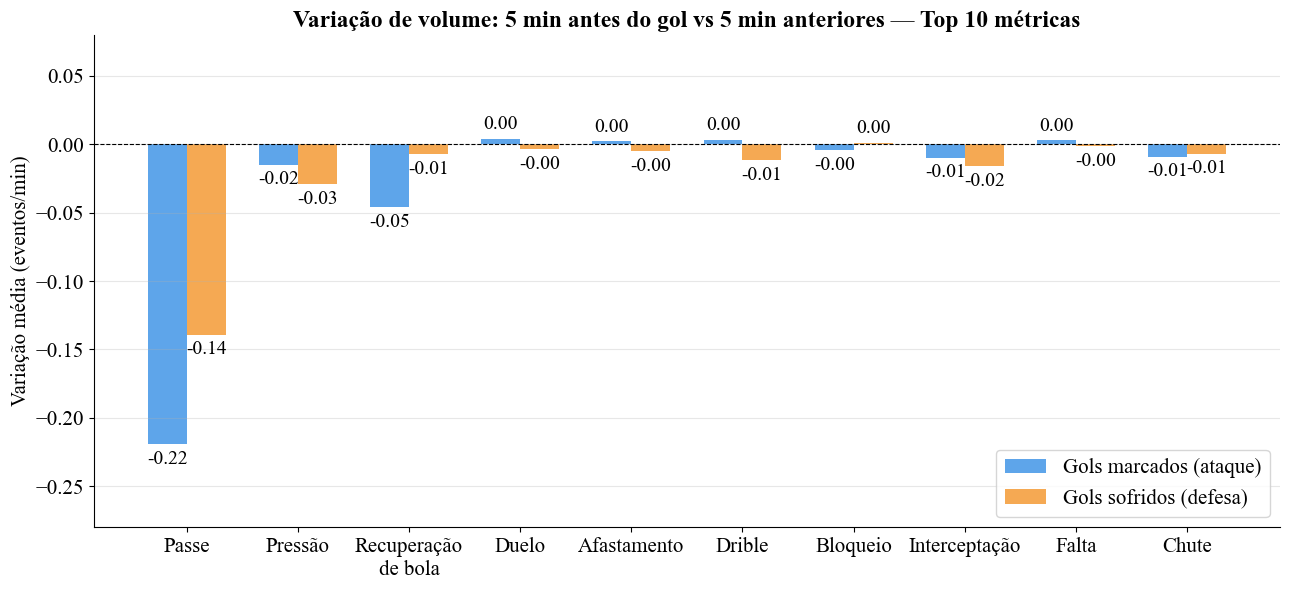

In [139]:
TOP10_METRICAS = [
    'passe', 'pressao', 'recuperacao', 'duelo_ganho',
    'corte', 'drible_certo', 'chute_bloqueado', 'interceptacao', 'falta', 'chute',
]
TOP10_METRICAS = [m for m in TOP10_METRICAS if f'{m}_diff_pm' in lags_15min.columns]

LABELS_PT_15 = {
    'passe': 'Passe', 'passe_certo': 'Passe certo', 'passe_errado': 'Passe errado',
    'pressao': 'Pressão', 'recuperacao': 'Recuperação\nde bola',
    'duelo_ganho': 'Duelo', 'corte': 'Afastamento', 'drible_certo': 'Drible',
    'chute_bloqueado': 'Bloqueio', 'interceptacao': 'Interceptação',
    'falta': 'Falta', 'chute': 'Chute',
}

def plot_lag15_comparacao(lags_marcados, lags_sofridos, metricas, labels, titulo_sufixo='', savepath=None):
    ataque_vals = lags_marcados[[f'{m}_diff_pm' for m in metricas]].mean()
    defesa_vals = lags_sofridos[[f'{m}_diff_pm' for m in metricas]].mean()
    x = np.arange(len(metricas))
    width = 0.35
    plt.rcParams['font.family'] = 'Times New Roman'
    fig, ax = plt.subplots(figsize=(13, 6))
    bars1 = ax.bar(x - width/2, [ataque_vals[f'{m}_diff_pm'] for m in metricas],
                   width, label='Gols marcados (ataque)', color='#4C9BE8', alpha=0.9)
    bars2 = ax.bar(x + width/2, [defesa_vals[f'{m}_diff_pm'] for m in metricas],
                   width, label='Gols sofridos (defesa)', color='#F4A040', alpha=0.9)
    ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([labels.get(m, m) for m in metricas], rotation=0, ha='center', fontsize=12)
    ax.set_ylabel('Variação média (eventos/min)', fontsize=15)
    ax.set_title(
        f'Variação de volume: 15 min antes do gol vs 15 min anteriores{titulo_sufixo}',
        fontsize=17, fontweight='bold'
    )
    ax.legend(fontsize=15, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3)
    offset = 0.004
    for bar in list(bars1) + list(bars2):
        v = bar.get_height()
        if v >= 0:
            ax.text(bar.get_x() + bar.get_width()/2, v + offset,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=14)
        else:
            ax.text(bar.get_x() + bar.get_width()/2, v - offset,
                    f'{v:.2f}', ha='center', va='top', fontsize=14)
    ax.set_ylim(-0.28, 0.08)
    ax.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=200, facecolor='white')
    plt.show()

print('=== Top 10 métricas (janela 15 min) ===')
plot_lag5_comparacao(lags_15min, lags_sofrer_15min, TOP10_METRICAS, LABELS_PT_15, ' — Top 10 métricas', savepath='../figures/fig_lag15_comparacao_top10.png')

#### Partidas selecionadas — visualização para dissertação

Versão com sombreamento das janelas lag10 e lag10\_antes, título e legenda explicativos.

In [140]:
def preparar_partida(
    events_minuto,
    match_id,
    min_minuto_gol=20
):
    """
    Prepara os dados de uma partida para visualização e análise temporal.

    Regras metodológicas (EXPLÍCITAS):
    - Considera APENAS gols de open play
      (exclui Free Kick, Penalty e Corner)
    - Considera apenas gols com minute_in_period >= min_minuto_gol
      (garante janelas pré-gol completas)
    """

    # --------------------------------------------------
    # 1) Filtrar partida
    # --------------------------------------------------
    df_match = (
        events_minuto
            .query("match_id == @match_id")
            .copy()
    )

    # --------------------------------------------------
    # 2) Reforçar OPEN PLAY (filtro redundante e explícito)
    # --------------------------------------------------
    if "shot_type" in df_match.columns:
        df_match = df_match[
            ~df_match["shot_type"].isin(
                ["Free Kick", "Penalty", "Corner"]
            )
        ].copy()

    # --------------------------------------------------
    # 3) Times e períodos
    # --------------------------------------------------
    times = df_match["team"].unique()
    periods = sorted(df_match["period"].unique())

    # --------------------------------------------------
    # 4) Criar grade completa (time x período x minuto)
    # --------------------------------------------------
    max_minutos = (
        df_match
            .groupby("period")["minute_in_period"]
            .max()
            .dropna()
            .astype(int)
            .to_dict()
    )

    grades = []

    for p in periods:
        grade_p = (
            pd.MultiIndex
                .from_product(
                    [times, [p], range(0, max_minutos[p] + 1)],
                    names=["team", "period", "minute_in_period"]
                )
                .to_frame(index=False)
        )
        grades.append(grade_p)

    grade = pd.concat(grades, ignore_index=True)

    df_match = (
        grade
            .merge(
                df_match,
                on=["team", "period", "minute_in_period"],
                how="left"
            )
            .fillna(0)
    )

    # --------------------------------------------------
    # 5) Derivar gols válidos da partida
    #    - open play
    #    - após min_minuto_gol
    # --------------------------------------------------
    gols = (
        df_match
            .query(
                "gol > 0 and minute_in_period >= @min_minuto_gol"
            )
            [["team", "period", "minute_in_period"]]
            .sort_values(["period", "minute_in_period"])
            .reset_index(drop=True)
    )

    return df_match, gols


In [141]:
def plot_partida_dissertacao(
    events_minuto,
    match_id,
    metrica_base='passe',
    min_minuto_gol=20,
    nome_partida=None,
    savepath=None,
):
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines

    plt.rcParams['font.family'] = 'Times New Roman'
    metrica_mm = f'{metrica_base}_mm10'
    LABELS_PT = {'passe': 'Passe', 'passe_certo': 'Passe certo', 'passe_errado': 'Passe errado'}
    metrica_label = LABELS_PT.get(metrica_base, metrica_base)

    df_match, gols_match = preparar_partida(events_minuto, match_id, min_minuto_gol=min_minuto_gol)

    df_match = df_match.sort_values(['team', 'period', 'minute_in_period'])
    df_match[metrica_mm] = (
        df_match.groupby(['team', 'period'])[metrica_base]
        .rolling(window=10, min_periods=1).mean()
        .reset_index(level=[0,1], drop=True)
    )

    times = df_match['team'].unique()
    assert len(times) == 2
    cores = ['#4C9BE8', '#F4A040']

    if nome_partida is None:
        nome_partida = f'Partida {match_id}'

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')
    fig.suptitle(
        f'Partida: {nome_partida}\n'
        f'Métrica: {metrica_label} (média móvel de 10 minutos)',
        fontsize=25, fontweight='bold'
    )

    for row, (time_plot, cor) in enumerate(zip(times, cores)):
        time_adv = [t for t in times if t != time_plot][0]
        for col, periodo in enumerate([1, 2]):
            ax = axes[row][col]
            dados = df_match[(df_match['team'] == time_plot) & (df_match['period'] == periodo)]

            ax.plot(dados['minute_in_period'], dados[metrica_mm], color=cor, linewidth=2)

            gols_time = gols_match[(gols_match['team'] == time_plot) & (gols_match['period'] == periodo)]
            gols_adv  = gols_match[(gols_match['team'] == time_adv)  & (gols_match['period'] == periodo)]
            todos_gols = pd.concat([
                gols_time.assign(tipo='proprio'),
                gols_adv.assign(tipo='adversario')
            ])

            ymin_ax, ymax_ax = dados[metrica_mm].min(), dados[metrica_mm].max()
            y_span = max(ymax_ax - ymin_ax, 0.5)

            for _, g in todos_gols.iterrows():
                t = g['minute_in_period']

                # Janelas
                lag_mins   = dados[(dados['minute_in_period'] >= t-10) & (dados['minute_in_period'] <= t-1)]
                antes_mins = dados[(dados['minute_in_period'] >= t-20) & (dados['minute_in_period'] <= t-11)]
                media_lag   = lag_mins[metrica_base].sum() / 10.0  # eventos/min
                media_antes = antes_mins[metrica_base].sum() / 10.0

                # Sombreamento
                ax.axvspan(max(0, t-10), t-1,  alpha=0.15, color='#2196F3', zorder=0)
                ax.axvspan(max(0, t-20), t-11, alpha=0.15, color='#FF9800', zorder=0)

                # Anotações de média — posição fixa em coordenadas de eixo (transAxes)
                max_min_ax = int(dados['minute_in_period'].max()) if len(dados) > 0 else 45
                mid_lag_x   = (max(0, t-10) + (t-1)) / 2 / max_min_ax
                mid_antes_x = (max(0, t-20) + (t-11)) / 2 / max_min_ax
                ax.text(mid_lag_x,   0.97, f'{media_lag:.1f}/min',   ha='center', va='top',
                        fontsize=20, color='#1565C0', fontweight='bold',
                        transform=ax.transAxes)
                ax.text(mid_antes_x, 0.97, f'{media_antes:.1f}/min', ha='center', va='top',
                        fontsize=20, color='#E65100', fontweight='bold',
                        transform=ax.transAxes)

                # Linha vertical do gol
                ls = '--' if g['tipo'] == 'proprio' else ':'
                lw = 2   if g['tipo'] == 'proprio' else 1.8
                lc = cor if g['tipo'] == 'proprio' else 'black'
                ax.axvline(t, color=lc, linestyle=ls, linewidth=lw, alpha=0.9)

            ax.set_title(f'{time_plot} — {"1º tempo" if periodo == 1 else "2º tempo"}', fontsize=15, fontweight='bold')
            ax.set_xlabel('Minuto no período', fontsize=15)
            if col == 0:
                ax.set_ylabel(f'{metrica_label} / min (MM10)', fontsize=15)
            max_min = int(dados['minute_in_period'].max()) if len(dados) > 0 else 45
            ax.set_xticks(range(0, max_min + 1, 5))
            ax.tick_params(axis='both', labelsize=15)
            ax.grid(alpha=0.3)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    legend_elements = [
        mlines.Line2D([0],[0], color=cores[0], lw=2, label=f'{times[0]}'),
        mlines.Line2D([0],[0], color=cores[1], lw=2, label=f'{times[1]}'),
        mlines.Line2D([0],[0], color='gray', lw=2, linestyle='--', label='Gol do time (open play, t >= 20)'),
        mlines.Line2D([0],[0], color='black', lw=1.8, linestyle=':', label='Gol do adversário'),
        mpatches.Patch(color='#2196F3', alpha=0.3, label='Janela lag10 (t-10 a t-1) — média em azul'),
        mpatches.Patch(color='#FF9800', alpha=0.3, label='Janela lag10_antes (t-20 a t-11) — média em laranja'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=3,
               prop={'size': 22}, bbox_to_anchor=(0.5, -0.06), frameon=True)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150, facecolor='white')
    plt.show()


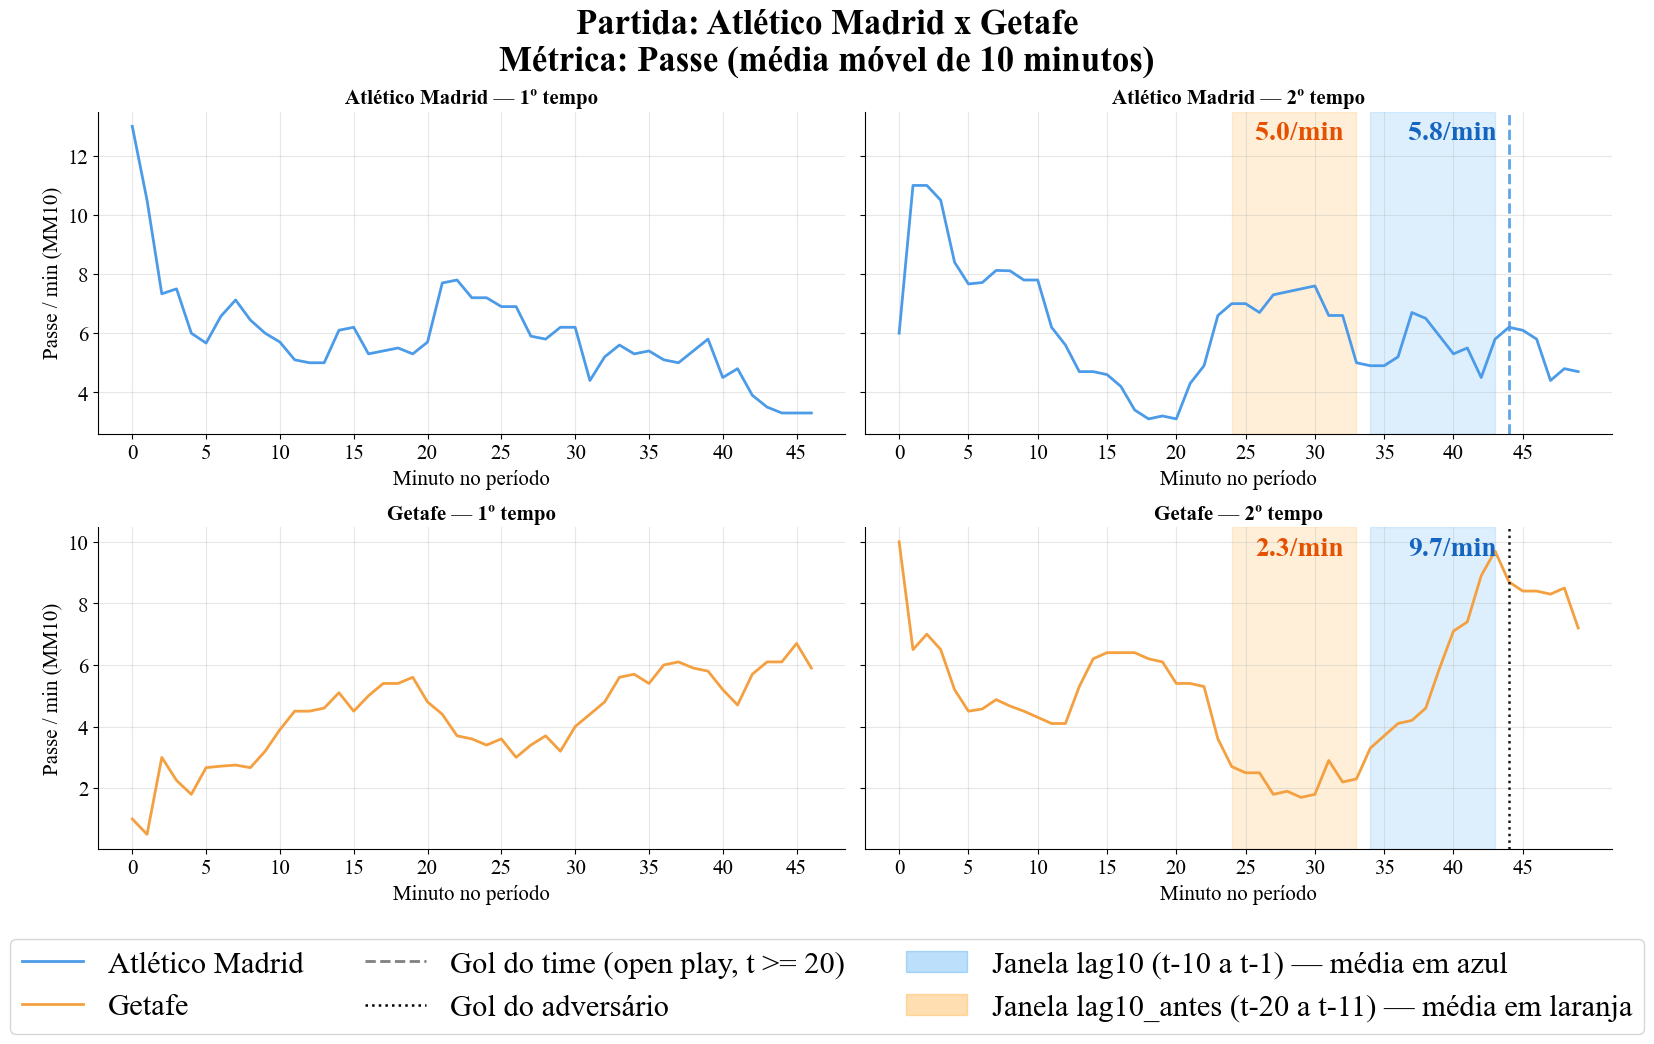

In [142]:
plot_partida_dissertacao(
    events_minuto,
    match_id=3825598,
    metrica_base='passe',
    nome_partida='Atlético Madrid x Getafe',
    savepath='../figures/fig_partida_atletico_getafe.png'
)


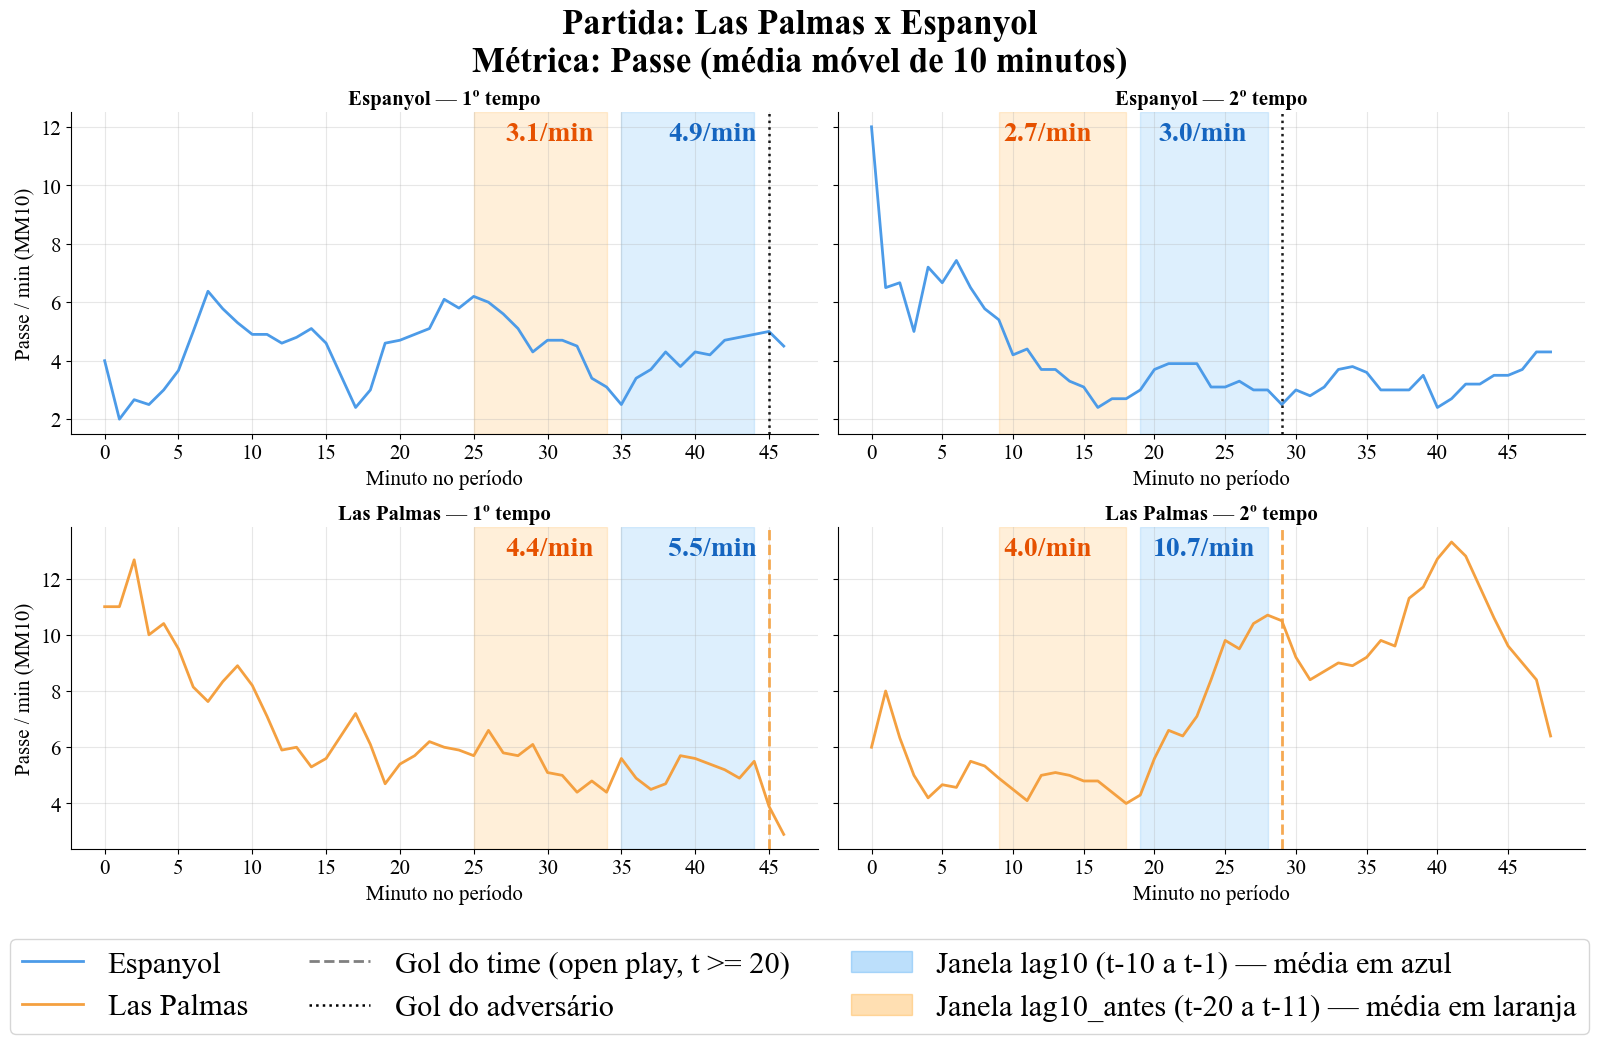

In [143]:
plot_partida_dissertacao(
    events_minuto,
    match_id=3825871,
    metrica_base='passe',
    nome_partida='Las Palmas x Espanyol',
    savepath='../figures/fig_partida_laspalmas_espanyol.png'
)


#### Partidas selecionadas — versão com valores brutos (sem média móvel)

Valores brutos por minuto em barras, com média das janelas calculada diretamente sobre os dados visíveis.

In [144]:
def plot_partida_dissertacao_v2(
    events_minuto,
    match_id,
    metrica_base='passe',
    min_minuto_gol=20,
    nome_partida=None,
    savepath=None,
):
    import matplotlib.patches as mpatches
    import matplotlib.lines as mlines

    plt.rcParams['font.family'] = 'Times New Roman'
    LABELS_PT = {'passe': 'Passe', 'passe_certo': 'Passe certo', 'passe_errado': 'Passe errado'}
    metrica_label = LABELS_PT.get(metrica_base, metrica_base)

    df_match, gols_match = preparar_partida(events_minuto, match_id, min_minuto_gol=min_minuto_gol)
    df_match = df_match.sort_values(['team', 'period', 'minute_in_period'])

    times = df_match['team'].unique()
    assert len(times) == 2
    cores = ['#4C9BE8', '#F4A040']

    if nome_partida is None:
        nome_partida = f'Partida {match_id}'

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey='row')
    fig.suptitle(
        f'Partida: {nome_partida}\n'
        f'Métrica: {metrica_label} (valores brutos por minuto)',
        fontsize=25, fontweight='bold'
    )

    for row, (time_plot, cor) in enumerate(zip(times, cores)):
        time_adv = [t for t in times if t != time_plot][0]
        for col, periodo in enumerate([1, 2]):
            ax = axes[row][col]
            dados = df_match[(df_match['team'] == time_plot) & (df_match['period'] == periodo)]

            # Barras de valores brutos
            ax.bar(dados['minute_in_period'], dados[metrica_base],
                   color=cor, alpha=0.6, width=0.8, zorder=2)

            gols_time = gols_match[(gols_match['team'] == time_plot) & (gols_match['period'] == periodo)]
            gols_adv  = gols_match[(gols_match['team'] == time_adv)  & (gols_match['period'] == periodo)]
            todos_gols = pd.concat([
                gols_time.assign(tipo='proprio'),
                gols_adv.assign(tipo='adversario')
            ])

            for _, g in todos_gols.iterrows():
                t = g['minute_in_period']

                lag_mins   = dados[(dados['minute_in_period'] >= t-10) & (dados['minute_in_period'] <= t-1)]
                antes_mins = dados[(dados['minute_in_period'] >= t-20) & (dados['minute_in_period'] <= t-11)]
                media_lag   = lag_mins[metrica_base].mean()
                media_antes = antes_mins[metrica_base].mean()

                # Linha horizontal da média dentro de cada janela
                if len(lag_mins) > 0:
                    ax.hlines(media_lag, t-10, t-1, colors='#1565C0', linewidth=2.5, zorder=3)
                if len(antes_mins) > 0:
                    ax.hlines(media_antes, t-20, t-11, colors='#E65100', linewidth=2.5, zorder=3)

                # Sombreamento
                ax.axvspan(max(0, t-10), t-1,  alpha=0.15, color='#2196F3', zorder=0)
                ax.axvspan(max(0, t-20), t-11, alpha=0.15, color='#FF9800', zorder=0)

                # Anotações de média
                max_min_ax = int(dados['minute_in_period'].max()) if len(dados) > 0 else 45
                mid_lag_x   = (max(0, t-10) + (t-1)) / 2 / max_min_ax
                mid_antes_x = (max(0, t-20) + (t-11)) / 2 / max_min_ax
                ax.text(mid_lag_x,   0.97, f'{media_lag:.1f}/min',   ha='center', va='top',
                        fontsize=20, color='#1565C0', fontweight='bold', transform=ax.transAxes)
                ax.text(mid_antes_x, 0.97, f'{media_antes:.1f}/min', ha='center', va='top',
                        fontsize=20, color='#E65100', fontweight='bold', transform=ax.transAxes)

                # Linha vertical do gol
                ls = '--' if g['tipo'] == 'proprio' else ':'
                lw = 2   if g['tipo'] == 'proprio' else 1.8
                lc = cor if g['tipo'] == 'proprio' else 'black'
                ax.axvline(t, color=lc, linestyle=ls, linewidth=lw, alpha=0.9)

            ax.set_title(f'{time_plot} — {"1º tempo" if periodo == 1 else "2º tempo"}', fontsize=15, fontweight='bold')
            ax.set_xlabel('Minuto no período', fontsize=15)
            if col == 0:
                ax.set_ylabel(f'{metrica_label} / min (bruto)', fontsize=15)
            max_min = int(dados['minute_in_period'].max()) if len(dados) > 0 else 45
            ax.set_xticks(range(0, max_min + 1, 5))
            ax.tick_params(axis='both', labelsize=12)
            ax.grid(axis='y', alpha=0.3)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

    legend_elements = [
        mpatches.Patch(color=cores[0], alpha=0.6, label=f'{times[0]}'),
        mpatches.Patch(color=cores[1], alpha=0.6, label=f'{times[1]}'),
        mlines.Line2D([0],[0], color='gray', lw=2, linestyle='--', label='Gol do time (open play, t >= 20)'),
        mlines.Line2D([0],[0], color='black', lw=1.8, linestyle=':', label='Gol do adversário'),
        mpatches.Patch(color='#2196F3', alpha=0.3, label='Janela lag10 (t-10 a t-1)'),
        mpatches.Patch(color='#FF9800', alpha=0.3, label='Janela lag10_antes (t-20 a t-11)'),
        mlines.Line2D([0],[0], color='#1565C0', lw=2.5, label='Média lag10'),
        mlines.Line2D([0],[0], color='#E65100', lw=2.5, label='Média lag10_antes'),
    ]
    fig.legend(handles=legend_elements, loc='lower center', ncol=4,
               prop={'size': 20}, bbox_to_anchor=(0.5, -0.06), frameon=True)
    plt.tight_layout(rect=[0, 0.07, 1, 1])
    if savepath:
        plt.savefig(savepath, bbox_inches='tight', dpi=150, facecolor='white')
    plt.show()


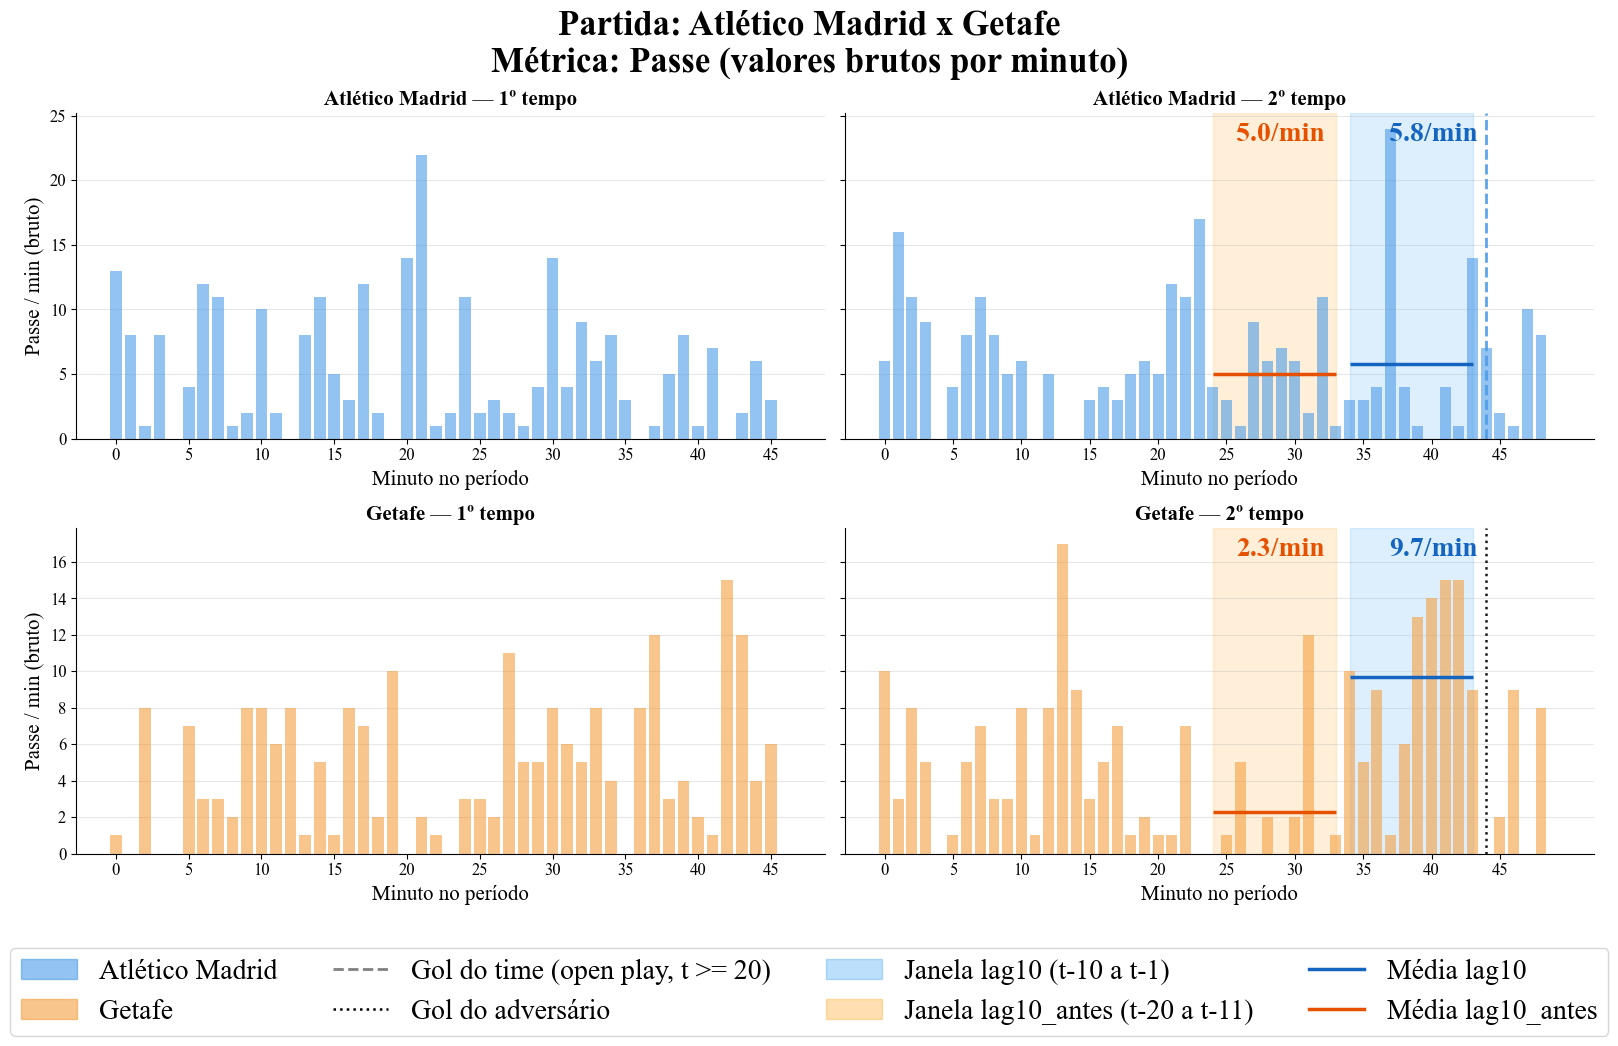

In [145]:
plot_partida_dissertacao_v2(
    events_minuto,
    match_id=3825598,
    metrica_base='passe',
    nome_partida='Atlético Madrid x Getafe',
    savepath='../figures/fig_partida_v2_atletico_getafe.png'
)


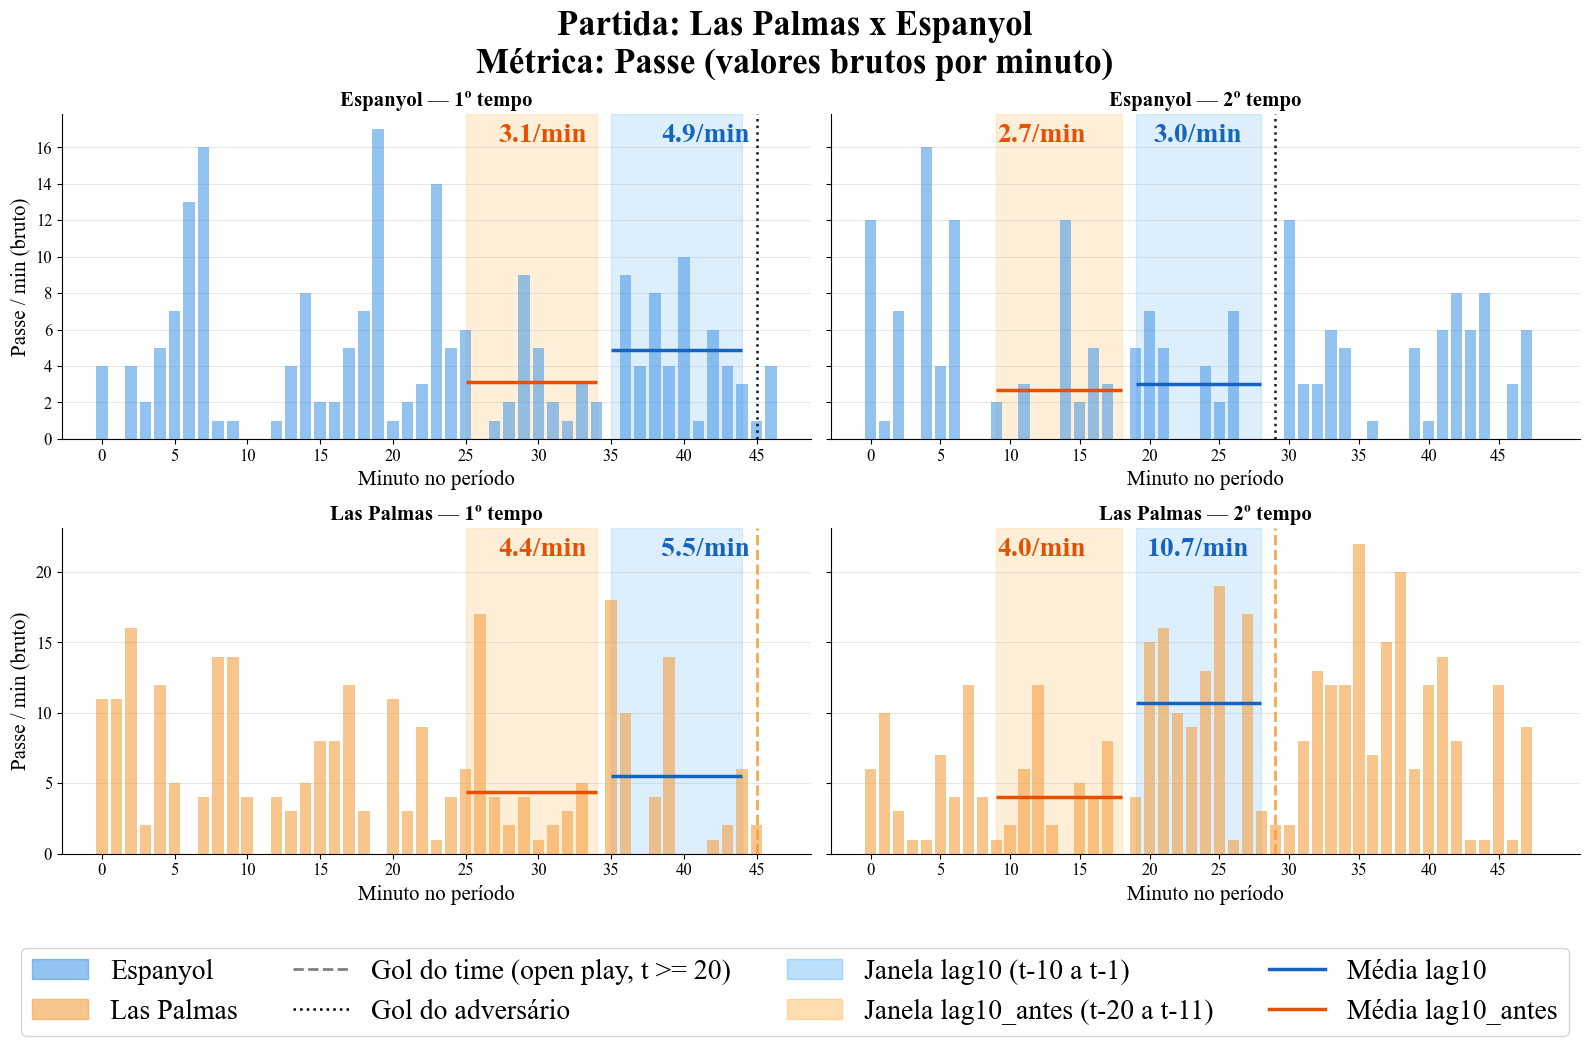

In [146]:
plot_partida_dissertacao_v2(
    events_minuto,
    match_id=3825871,
    metrica_base='passe',
    nome_partida='Las Palmas x Espanyol',
    savepath='../figures/fig_partida_v2_laspalmas_espanyol.png'
)


#### Correlação de Pearson: tipos de evento vs gol (janela K=10 min)

Para cada gol na temporada, contamos quantos eventos de cada tipo ocorreram nos K=10 minutos anteriores (mesmo time, mesmo período).  
Comparamos com janelas controle (sem gol próximo) para calcular o coeficiente de Pearson.  
Motivação: corrobora empiricamente a escolha de passes como feature do detector de drift.

Total gols: 1014
Janelas pré-gol: 1014 | Controle: 965


,Evento,r,p,significativo
8,Falta cometida,0.0866,0.0001,True
4,Afastamento,0.0895,0.0001,True
6,Bloqueio,0.1123,0.0000,True
7,Interceptação,0.1399,0.0000,True
3,Duelo,0.1998,0.0000,True
1,Pressão,0.2049,0.0000,True
5,Drible,0.2059,0.0000,True
9,Chute,0.2532,0.0000,True
2,Recuperação de bola,0.2750,0.0000,True
0,Passe,0.3063,0.0000,True


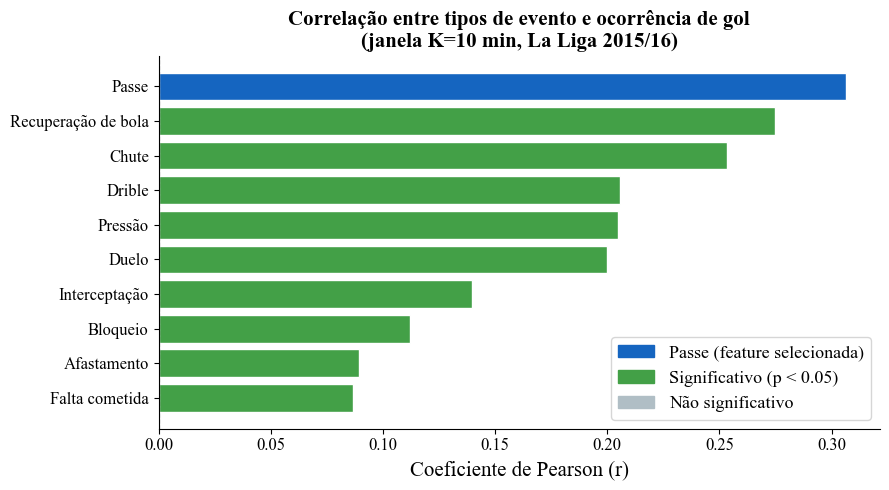

In [147]:
K = 10  # janela em minutos

TRADUCAO = {
    'Pass':           'Passe',
    'Pressure':        'Pressão',
    'Ball Recovery':   'Recuperação de bola',
    'Duel':            'Duelo',
    'Clearance':       'Afastamento',
    'Dribble':         'Drible',
    'Block':           'Bloqueio',
    'Interception':    'Interceptação',
    'Foul Committed':  'Falta cometida',
    'Shot':            'Chute',
}

TIPOS = [
    'Pass', 'Pressure', 'Ball Recovery', 'Duel', 'Clearance',
    'Dribble', 'Block', 'Interception', 'Foul Committed', 'Shot'
]

# ── 1. Identifica gols (open play) ───────────────────────────────────────────
goals_df = df_events[
    (df_events['type'] == 'Shot') &
    (df_events['shot_outcome'] == 'Goal')
][['match_id', 'period', 'minute', 'team']].copy()

print(f'Total gols: {len(goals_df)}')

# ── 2. Monta janelas pré-gol e controle ──────────────────────────────────────
np.random.seed(42)
records = []

for (mid, period, team), grp in df_events.groupby(['match_id', 'period', 'team']):
    goal_minutes = goals_df[
        (goals_df['match_id'] == mid) &
        (goals_df['period'] == period) &
        (goals_df['team'] == team)
    ]['minute'].tolist()

    max_min = grp['minute'].max()

    # janelas pré-gol
    for t in goal_minutes:
        w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
        row = {'is_goal_window': 1}
        for tipo in TIPOS:
            row[tipo] = (w['type'] == tipo).sum()
        records.append(row)

    # janelas controle (mesmo número, minutos sem gol próximo)
    candidates = [
        m for m in range(K, int(max_min))
        if not any(abs(m - g) <= K for g in goal_minutes)
    ]
    n = len(goal_minutes)
    if len(candidates) >= n:
        for t in np.random.choice(candidates, n, replace=False):
            w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
            row = {'is_goal_window': 0}
            for tipo in TIPOS:
                row[tipo] = (w['type'] == tipo).sum()
            records.append(row)

df_corr = pd.DataFrame(records)
print(f"Janelas pré-gol: {df_corr['is_goal_window'].sum()} | Controle: {(df_corr['is_goal_window']==0).sum()}")

# ── 3. Calcula Pearson ────────────────────────────────────────────────────────
results = []
for tipo in TIPOS:
    r, p = pearsonr(df_corr[tipo], df_corr['is_goal_window'])
    results.append({'Evento': TRADUCAO.get(tipo, tipo), 'r': round(r, 4), 'p': round(p, 4),
                    'significativo': p < 0.05})

df_r = pd.DataFrame(results).sort_values('r', ascending=True)
display(df_r)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(figsize=(9, 5))

colors = [
    '#1565C0' if row['Evento'] == 'Passe'
    else '#43A047' if row['significativo']
    else '#B0BEC5'
    for _, row in df_r.iterrows()
]

ax.barh(df_r['Evento'], df_r['r'], color=colors, edgecolor='white')
ax.axvline(0, color='#333', lw=0.8, ls='--')
ax.set_xlabel('Coeficiente de Pearson (r)', fontsize=15)
ax.set_title(
    f'Correlação entre tipos de evento e ocorrência de gol\n'
    f'(janela K={K} min, La Liga 2015/16)',
    fontsize=15,
    fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leg = [
    Patch(color='#1565C0', label='Passe (feature selecionada)'),
    Patch(color='#43A047', label='Significativo (p < 0.05)'),
    Patch(color='#B0BEC5', label='Não significativo'),
]
ax.legend(handles=leg, fontsize=13, loc='lower right')

ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig('../figures/fig_pearson_eventos_gol.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

#### Correlação de Pearson: tipos de evento vs gol (janela K=5 min)

Para cada gol na temporada, contamos quantos eventos de cada tipo ocorreram nos K=5 minutos anteriores (mesmo time, mesmo período).  
Comparamos com janelas controle (sem gol próximo) para calcular o coeficiente de Pearson.  
Motivação: corrobora empiricamente a escolha de passes como feature do detector de drift.

Total gols: 1014
Janelas pré-gol: 1014 | Controle: 1014


,Evento,r,p,significativo
4,Afastamento,0.0674,0.0024,True
8,Falta cometida,0.0801,0.0003,True
6,Bloqueio,0.0973,0.0000,True
7,Interceptação,0.1020,0.0000,True
5,Drible,0.1562,0.0000,True
9,Chute,0.1705,0.0000,True
3,Duelo,0.1836,0.0000,True
1,Pressão,0.1935,0.0000,True
2,Recuperação de bola,0.2237,0.0000,True
0,Passe,0.2965,0.0000,True


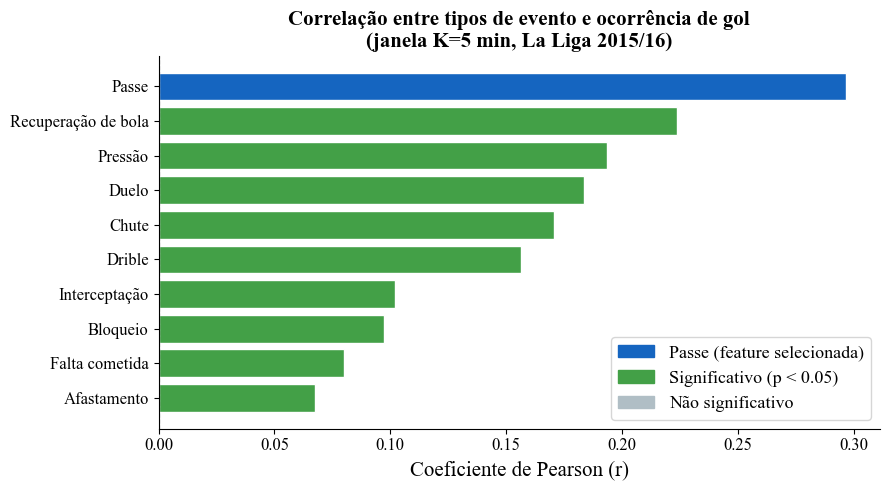

In [148]:
K = 5  # janela em minutos

TRADUCAO = {
    'Pass':           'Passe',
    'Pressure':        'Pressão',
    'Ball Recovery':   'Recuperação de bola',
    'Duel':            'Duelo',
    'Clearance':       'Afastamento',
    'Dribble':         'Drible',
    'Block':           'Bloqueio',
    'Interception':    'Interceptação',
    'Foul Committed':  'Falta cometida',
    'Shot':            'Chute',
}

TIPOS = [
    'Pass', 'Pressure', 'Ball Recovery', 'Duel', 'Clearance',
    'Dribble', 'Block', 'Interception', 'Foul Committed', 'Shot'
]

# ── 1. Identifica gols (open play) ───────────────────────────────────────────
goals_df = df_events[
    (df_events['type'] == 'Shot') &
    (df_events['shot_outcome'] == 'Goal')
][['match_id', 'period', 'minute', 'team']].copy()

print(f'Total gols: {len(goals_df)}')

# ── 2. Monta janelas pré-gol e controle ──────────────────────────────────────
np.random.seed(42)
records = []

for (mid, period, team), grp in df_events.groupby(['match_id', 'period', 'team']):
    goal_minutes = goals_df[
        (goals_df['match_id'] == mid) &
        (goals_df['period'] == period) &
        (goals_df['team'] == team)
    ]['minute'].tolist()

    max_min = grp['minute'].max()

    # janelas pré-gol
    for t in goal_minutes:
        w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
        row = {'is_goal_window': 1}
        for tipo in TIPOS:
            row[tipo] = (w['type'] == tipo).sum()
        records.append(row)

    # janelas controle (mesmo número, minutos sem gol próximo)
    candidates = [
        m for m in range(K, int(max_min))
        if not any(abs(m - g) <= K for g in goal_minutes)
    ]
    n = len(goal_minutes)
    if len(candidates) >= n:
        for t in np.random.choice(candidates, n, replace=False):
            w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
            row = {'is_goal_window': 0}
            for tipo in TIPOS:
                row[tipo] = (w['type'] == tipo).sum()
            records.append(row)

df_corr = pd.DataFrame(records)
print(f"Janelas pré-gol: {df_corr['is_goal_window'].sum()} | Controle: {(df_corr['is_goal_window']==0).sum()}")

# ── 3. Calcula Pearson ────────────────────────────────────────────────────────
results = []
for tipo in TIPOS:
    r, p = pearsonr(df_corr[tipo], df_corr['is_goal_window'])
    results.append({'Evento': TRADUCAO.get(tipo, tipo), 'r': round(r, 4), 'p': round(p, 4),
                    'significativo': p < 0.05})

df_r = pd.DataFrame(results).sort_values('r', ascending=True)
display(df_r)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(figsize=(9, 5))

colors = [
    '#1565C0' if row['Evento'] == 'Passe'
    else '#43A047' if row['significativo']
    else '#B0BEC5'
    for _, row in df_r.iterrows()
]

ax.barh(df_r['Evento'], df_r['r'], color=colors, edgecolor='white')
ax.axvline(0, color='#333', lw=0.8, ls='--')
ax.set_xlabel('Coeficiente de Pearson (r)', fontsize=15)
ax.set_title(
    f'Correlação entre tipos de evento e ocorrência de gol\n'
    f'(janela K={K} min, La Liga 2015/16)',
    fontsize=15,
    fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leg = [
    Patch(color='#1565C0', label='Passe (feature selecionada)'),
    Patch(color='#43A047', label='Significativo (p < 0.05)'),
    Patch(color='#B0BEC5', label='Não significativo'),
]
ax.legend(handles=leg, fontsize=13, loc='lower right')

ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig('../figures/fig_pearson_eventos_gol.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

#### Correlação de Pearson: tipos de evento vs gol (janela K=15 min)

Para cada gol na temporada, contamos quantos eventos de cada tipo ocorreram nos K=15 minutos anteriores (mesmo time, mesmo período).  
Comparamos com janelas controle (sem gol próximo) para calcular o coeficiente de Pearson.  
Motivação: corrobora empiricamente a escolha de passes como feature do detector de drift.

Total gols: 1014
Janelas pré-gol: 1014 | Controle: 874


,Evento,r,p,significativo
4,Afastamento,0.1246,0.0,True
6,Bloqueio,0.1520,0.0,True
8,Falta cometida,0.1633,0.0,True
7,Interceptação,0.1945,0.0,True
3,Duelo,0.2209,0.0,True
5,Drible,0.2585,0.0,True
1,Pressão,0.2624,0.0,True
9,Chute,0.2721,0.0,True
2,Recuperação de bola,0.2990,0.0,True
0,Passe,0.3576,0.0,True


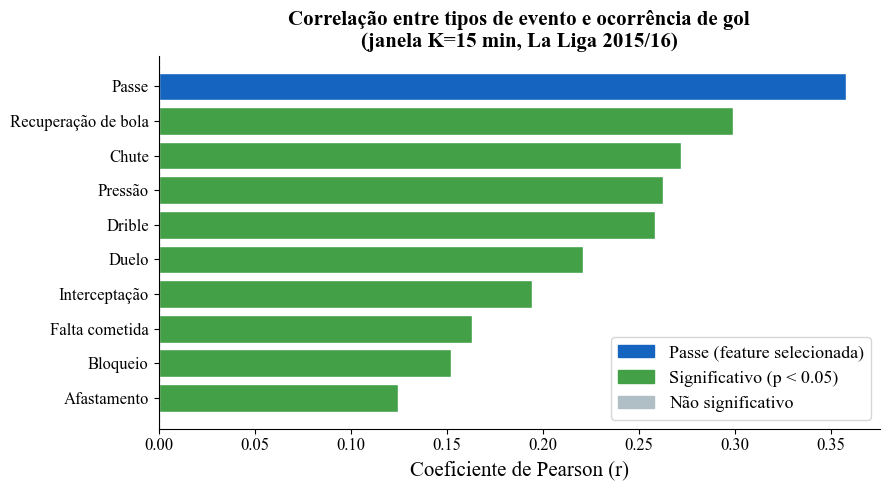

In [149]:
K = 15  # janela em minutos

TRADUCAO = {
    'Pass':           'Passe',
    'Pressure':        'Pressão',
    'Ball Recovery':   'Recuperação de bola',
    'Duel':            'Duelo',
    'Clearance':       'Afastamento',
    'Dribble':         'Drible',
    'Block':           'Bloqueio',
    'Interception':    'Interceptação',
    'Foul Committed':  'Falta cometida',
    'Shot':            'Chute',
}

TIPOS = [
    'Pass', 'Pressure', 'Ball Recovery', 'Duel', 'Clearance',
    'Dribble', 'Block', 'Interception', 'Foul Committed', 'Shot'
]

# ── 1. Identifica gols (open play) ───────────────────────────────────────────
goals_df = df_events[
    (df_events['type'] == 'Shot') &
    (df_events['shot_outcome'] == 'Goal')
][['match_id', 'period', 'minute', 'team']].copy()

print(f'Total gols: {len(goals_df)}')

# ── 2. Monta janelas pré-gol e controle ──────────────────────────────────────
np.random.seed(42)
records = []

for (mid, period, team), grp in df_events.groupby(['match_id', 'period', 'team']):
    goal_minutes = goals_df[
        (goals_df['match_id'] == mid) &
        (goals_df['period'] == period) &
        (goals_df['team'] == team)
    ]['minute'].tolist()

    max_min = grp['minute'].max()

    # janelas pré-gol
    for t in goal_minutes:
        w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
        row = {'is_goal_window': 1}
        for tipo in TIPOS:
            row[tipo] = (w['type'] == tipo).sum()
        records.append(row)

    # janelas controle (mesmo número, minutos sem gol próximo)
    candidates = [
        m for m in range(K, int(max_min))
        if not any(abs(m - g) <= K for g in goal_minutes)
    ]
    n = len(goal_minutes)
    if len(candidates) >= n:
        for t in np.random.choice(candidates, n, replace=False):
            w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
            row = {'is_goal_window': 0}
            for tipo in TIPOS:
                row[tipo] = (w['type'] == tipo).sum()
            records.append(row)

df_corr = pd.DataFrame(records)
print(f"Janelas pré-gol: {df_corr['is_goal_window'].sum()} | Controle: {(df_corr['is_goal_window']==0).sum()}")

# ── 3. Calcula Pearson ────────────────────────────────────────────────────────
results = []
for tipo in TIPOS:
    r, p = pearsonr(df_corr[tipo], df_corr['is_goal_window'])
    results.append({'Evento': TRADUCAO.get(tipo, tipo), 'r': round(r, 4), 'p': round(p, 4),
                    'significativo': p < 0.05})

df_r = pd.DataFrame(results).sort_values('r', ascending=True)
display(df_r)

# ── 4. Plot ───────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'
fig, ax = plt.subplots(figsize=(9, 5))

colors = [
    '#1565C0' if row['Evento'] == 'Passe'
    else '#43A047' if row['significativo']
    else '#B0BEC5'
    for _, row in df_r.iterrows()
]

ax.barh(df_r['Evento'], df_r['r'], color=colors, edgecolor='white')
ax.axvline(0, color='#333', lw=0.8, ls='--')
ax.set_xlabel('Coeficiente de Pearson (r)', fontsize=15)
ax.set_title(
    f'Correlação entre tipos de evento e ocorrência de gol\n'
    f'(janela K={K} min, La Liga 2015/16)',
    fontsize=15,
    fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

leg = [
    Patch(color='#1565C0', label='Passe (feature selecionada)'),
    Patch(color='#43A047', label='Significativo (p < 0.05)'),
    Patch(color='#B0BEC5', label='Não significativo'),
]
ax.legend(handles=leg, fontsize=13, loc='lower right')

ax.tick_params(axis='both', labelsize=12)
plt.tight_layout()
plt.savefig('../figures/fig_pearson_eventos_gol.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

#### Comparação Correlação de Pearsonn Entre 3 Valores de K

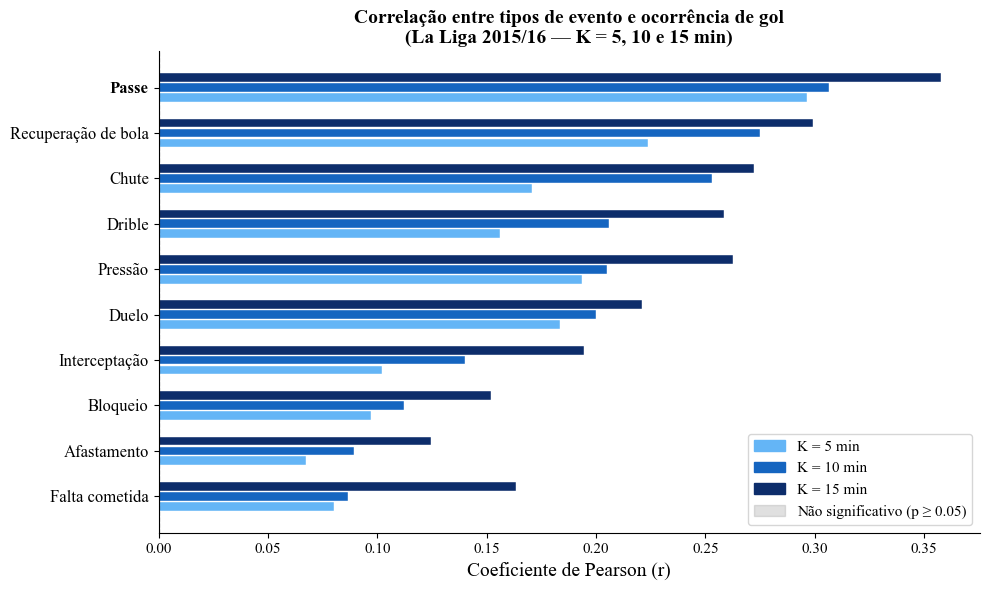

In [150]:
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

TRADUCAO = {
    'Pass':           'Passe',
    'Pressure':        'Pressão',
    'Ball Recovery':   'Recuperação de bola',
    'Duel':            'Duelo',
    'Clearance':       'Afastamento',
    'Dribble':         'Drible',
    'Block':           'Bloqueio',
    'Interception':    'Interceptação',
    'Foul Committed':  'Falta cometida',
    'Shot':            'Chute',
}
TIPOS = list(TRADUCAO.keys())

def compute_pearson(K):
    goals_df = df_events[
        (df_events['type'] == 'Shot') &
        (df_events['shot_outcome'] == 'Goal')
    ][['match_id', 'period', 'minute', 'team']].copy()

    np.random.seed(42)
    records = []

    for (mid, period, team), grp in df_events.groupby(['match_id', 'period', 'team']):
        goal_minutes = goals_df[
            (goals_df['match_id'] == mid) &
            (goals_df['period'] == period) &
            (goals_df['team'] == team)
        ]['minute'].tolist()

        max_min = grp['minute'].max()

        for t in goal_minutes:
            w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
            row = {'is_goal_window': 1}
            for tipo in TIPOS:
                row[tipo] = (w['type'] == tipo).sum()
            records.append(row)

        candidates = [
            m for m in range(K, int(max_min))
            if not any(abs(m - g) <= K for g in goal_minutes)
        ]
        n = len(goal_minutes)
        if len(candidates) >= n:
            for t in np.random.choice(candidates, n, replace=False):
                w = grp[(grp['minute'] >= t - K) & (grp['minute'] < t)]
                row = {'is_goal_window': 0}
                for tipo in TIPOS:
                    row[tipo] = (w['type'] == tipo).sum()
                records.append(row)

    df_corr = pd.DataFrame(records)
    results = []
    for tipo in TIPOS:
        r, p = pearsonr(df_corr[tipo], df_corr['is_goal_window'])
        results.append({'Evento': TRADUCAO[tipo], 'r': round(r, 4), 'p': round(p, 4), 'sig': p < 0.05})
    return pd.DataFrame(results)

dfs = {K: compute_pearson(K) for K in [5, 10, 15]}

# ordena eventos pelo r de K=10
order = dfs[10].sort_values('r')['Evento'].tolist()

merged = pd.DataFrame({'Evento': order})
for K in [5, 10, 15]:
    idx = dfs[K].set_index('Evento')
    merged[f'r_{K}']   = merged['Evento'].map(idx['r'])
    merged[f'sig_{K}'] = merged['Evento'].map(idx['sig'])

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'

K_VALS   = [5,        10,       15]
K_COLORS = ['#64B5F6', '#1565C0', '#0D2D6B']   # azul claro → escuro

bar_h  = 0.22
n      = len(order)
y_base = np.arange(n)
offsets = np.array([-1, 0, 1]) * bar_h

fig, ax = plt.subplots(figsize=(10, 6))

for K, color, off in zip(K_VALS, K_COLORS, offsets):
    for j, evento in enumerate(merged['Evento']):
        r_val = merged.loc[j, f'r_{K}']
        sig   = merged.loc[j, f'sig_{K}']
        alpha = 1.0 if sig else 0.30
        ax.barh(y_base[j] + off, r_val, height=bar_h * 0.88,
                color=color, alpha=alpha, edgecolor='white', linewidth=0.3)

ax.axvline(0, color='#333', lw=0.8, ls='--')

ax.set_yticks(y_base)
ax.set_yticklabels(order, fontsize=12)
for lbl in ax.get_yticklabels():
    if lbl.get_text() == 'Passe':
        lbl.set_fontweight('bold')

ax.set_xlabel('Coeficiente de Pearson (r)', fontsize=14)
ax.set_title(
    'Correlação entre tipos de evento e ocorrência de gol\n'
    '(La Liga 2015/16 — K = 5, 10 e 15 min)',
    fontsize=14, fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=11)

leg = [
    Patch(color='#64B5F6', label='K = 5 min'),
    Patch(color='#1565C0', label='K = 10 min'),
    Patch(color='#0D2D6B', label='K = 15 min'),
    Patch(color='#999999', alpha=0.30, label='Não significativo (p ≥ 0.05)'),
]
ax.legend(handles=leg, fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig('../figures/fig_pearson_comparacao_k.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


#### Quem marcou primeiro venceu a partida?

Análise de 353 partidas com ao menos um gol (La Liga 2015/16).

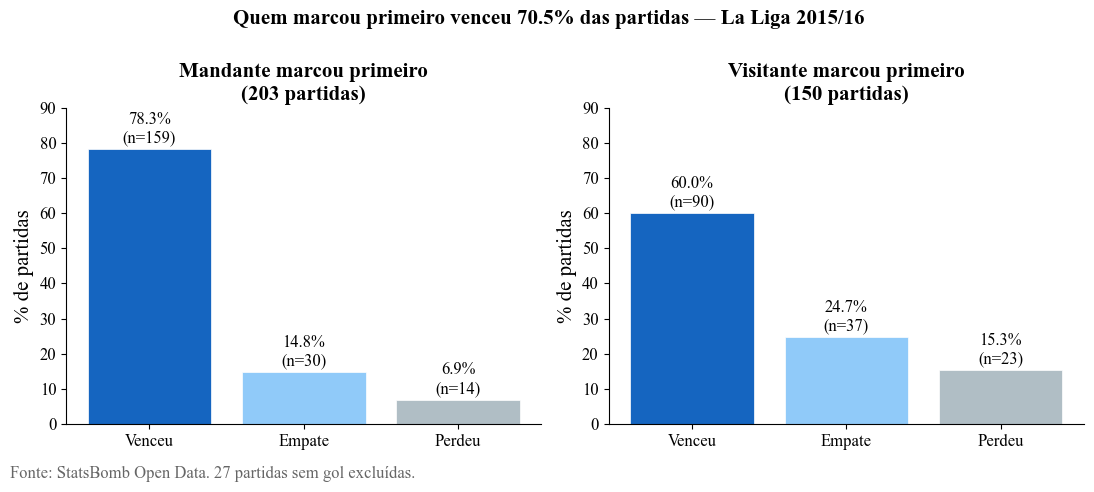

Partidas sem gol: 27


In [151]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_wide = pd.read_parquet('../data/processed/events_wide_minute.parquet')

# Resultado final por partida
match_result = (
    df_wide.groupby('match_id')
    .agg(home_team=('home_team','first'), away_team=('away_team','first'),
         gols_casa=('gol_casa','sum'), gols_fora=('gol_fora','sum'))
    .reset_index()
)
match_result['winner'] = match_result.apply(
    lambda r: 'casa' if r['gols_casa'] > r['gols_fora']
    else ('fora' if r['gols_fora'] > r['gols_casa'] else 'empate'), axis=1)

# Primeiro minuto com gol em cada partida
has_goal = df_wide[(df_wide['gol_casa'] > 0) | (df_wide['gol_fora'] > 0)].copy()
first_goal = (
    has_goal.groupby('match_id')[['gol_casa','gol_fora']]
    .first().reset_index()
)
first_goal['first_scorer'] = first_goal.apply(
    lambda r: 'casa' if r['gol_casa'] > 0 else 'fora', axis=1)

merged = match_result.merge(first_goal[['match_id','first_scorer']], on='match_id', how='left')
has_first = merged.dropna(subset=['first_scorer']).copy()

# ── Figura ──────────────────────────────────────────────────────────────────
plt.rcParams['font.family'] = 'Times New Roman'
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

LABELS   = ['Venceu', 'Empate', 'Perdeu']
COLORS   = ['#1565C0', '#90CAF9', '#B0BEC5']
SCORERS  = ['casa', 'fora']
TITLES   = ['Mandante marcou primeiro', 'Visitante marcou primeiro']

for ax, scorer, title in zip(axes, SCORERS, TITLES):
    sub  = has_first[has_first['first_scorer'] == scorer]
    n    = len(sub)
    venc = (sub['winner'] == scorer).sum()
    emp  = (sub['winner'] == 'empate').sum()
    perd = n - venc - emp
    vals = [venc, emp, perd]
    pcts = [100*v/n for v in vals]

    bars = ax.bar(LABELS, pcts, color=COLORS, edgecolor='white', linewidth=0.5)
    for bar, pct, v in zip(bars, pcts, vals):
        ax.text(bar.get_x() + bar.get_width()/2, pct + 0.8,
                f'{pct:.1f}%\n(n={v})', ha='center', va='bottom', fontsize=12)
    ax.set_title(f'{title}\n({n} partidas)', fontsize=15, fontweight='bold')
    ax.set_ylabel('% de partidas', fontsize=15)
    ax.set_ylim(0, 90)
    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

total  = len(has_first)
ganhou = (has_first['first_scorer'] == has_first['winner']).sum()
fig.suptitle(
    f'Quem marcou primeiro venceu {100*ganhou/total:.1f}% das partidas — La Liga 2015/16',
    fontsize=15, fontweight='bold', y=1.01
)
fig.text(0.01, -0.03,
         'Fonte: StatsBomb Open Data. 27 partidas sem gol excluídas.',
         fontsize=12, color='#666')
plt.tight_layout()
plt.savefig('../figures/fig_primeiro_gol_resultado.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Partidas sem gol: {380 - total}')

In [152]:
from scipy.stats import chi2_contingency, binomtest

# ── 1. Teste Binomial ────────────────────────────────────────────────────────
# H0: P(vencer | marcou primeiro) = 0.5
# H1: P(vencer | marcou primeiro) > 0.5
total   = len(has_first)
ganhou  = int((has_first['first_scorer'] == has_first['winner']).sum())
binom   = binomtest(ganhou, total, p=0.5, alternative='greater')

print('=== Teste Binomial ===')
print(f'Sucessos (venceu): {ganhou}/{total} = {ganhou/total:.1%}')
print(f'p-valor (H0: p=0.5, unilateral): {binom.pvalue:.2e}')
print(f'Intervalo de confiança 95% (proporção): [{binom.proportion_ci(0.95).low:.3f}, {binom.proportion_ci(0.95).high:.3f}]')
print()

# ── 2. Qui-quadrado: primeiro a marcar × resultado ───────────────────────────
# Tabela de contingência: first_scorer (casa/fora) × winner (mesmo/empate/outro)
def outcome(row):
    if row['winner'] == row['first_scorer']:   return 'Venceu'
    if row['winner'] == 'empate':              return 'Empate'
    return 'Perdeu'

has_first = has_first.copy()
has_first['outcome'] = has_first.apply(outcome, axis=1)

ct = pd.crosstab(has_first['first_scorer'], has_first['outcome'],
                 rownames=['Marcou primeiro'], colnames=['Resultado'])
ct = ct[['Venceu', 'Empate', 'Perdeu']]   # ordem legível
print('=== Tabela de Contingência ===')
display(ct)

chi2, p_chi2, dof, expected = chi2_contingency(ct)
print(f'\nQui-quadrado: chi2={chi2:.3f} | gl={dof} | p-valor={p_chi2:.4f}')
print()

# ── 3. Resumo interpretativo ─────────────────────────────────────────────────
alpha = 0.05
print('=== Conclusão ===')
if binom.pvalue < alpha:
    print(f'[Binomial] Rejeita H0 (p={binom.pvalue:.2e} < {alpha}): '
          f'marcar primeiro aumenta significativamente a chance de vitória ({ganhou/total:.1%}).')
else:
    print(f'[Binomial] Não rejeita H0 (p={binom.pvalue:.2e}).')

if p_chi2 < alpha:
    print(f'[Qui-quadrado] Rejeita independência (p={p_chi2:.4f} < {alpha}): '
          'o resultado está associado a quem marcou primeiro.')
else:
    print(f'[Qui-quadrado] Não rejeita independência (p={p_chi2:.4f}).')

=== Teste Binomial ===
Sucessos (venceu): 249/353 = 70.5%
p-valor (H0: p=0.5, unilateral): 3.75e-15
Intervalo de confiança 95% (proporção): [0.663, 1.000]

=== Tabela de Contingência ===


Resultado,Venceu,Empate,Perdeu
Marcou primeiro,,,
casa,159,30,14
fora,90,37,23



Qui-quadrado: chi2=14.408 | gl=2 | p-valor=0.0007

=== Conclusão ===
[Binomial] Rejeita H0 (p=3.75e-15 < 0.05): marcar primeiro aumenta significativamente a chance de vitória (70.5%).
[Qui-quadrado] Rejeita independência (p=0.0007 < 0.05): o resultado está associado a quem marcou primeiro.
